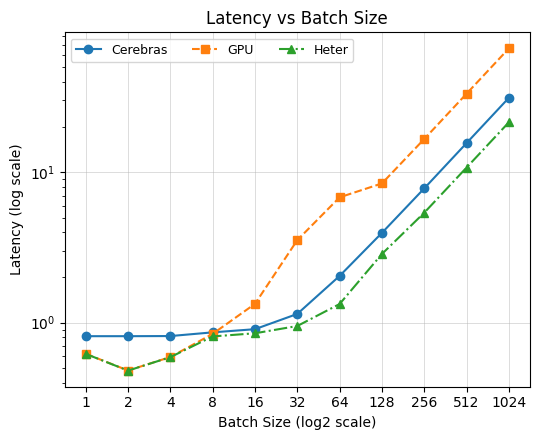

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Batch sizes
x = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024], dtype=float)

# Latency data
cerebras = np.array([
    0.813008130081301, 0.813008130081301, 0.814663951120163, 0.862068965517241,
    0.904977375565611, 1.14285714285714, 2.04472843450479, 3.95061728395062,
    7.80487804878049, 15.609756097561, 31.219512195122
], dtype=float)

gpu = np.array([
    0.62111801242236, 0.480769230769231, 0.590841949778434, 0.842105263157895,
    1.33333333333333, 3.53591160220994, 6.80851063829787, 8.42105263157895,
    16.6233766233766, 33.2467532467532, 66.4935064935064
], dtype=float)

heter = np.array([
    0.62, 0.48, 0.59, 0.81, 0.85, 0.95, 1.33, 2.86, 5.3781512605042,
    10.7337526205451, 21.4675052410901
], dtype=float)

# Plot (6:4 aspect ratio)
plt.figure(figsize=(5.5, 4.5))
plt.plot(x, cerebras, linestyle='-',  marker='o', label='Cerebras')
plt.plot(x, gpu,      linestyle='--', marker='s', label='GPU')
plt.plot(x, heter,    linestyle='-.', marker='^', label='Heter')

plt.xscale('log', base=2)   # log2 x-axis for batch size
plt.yscale('log')           # log y-axis for latency
plt.xticks(x, [str(int(v)) for v in x])

plt.xlabel('Batch Size (log2 scale)')
plt.ylabel('Latency (log scale)')
plt.title('Latency vs Batch Size')
plt.grid(True, linewidth=0.5, alpha=0.6)
plt.legend(ncol=3, fontsize=9, loc='upper left')
plt.tight_layout()

# Save (optional)
#plt.savefig('latency_line_logy_6x4.png', dpi=300, bbox_inches='tight')

plt.show()


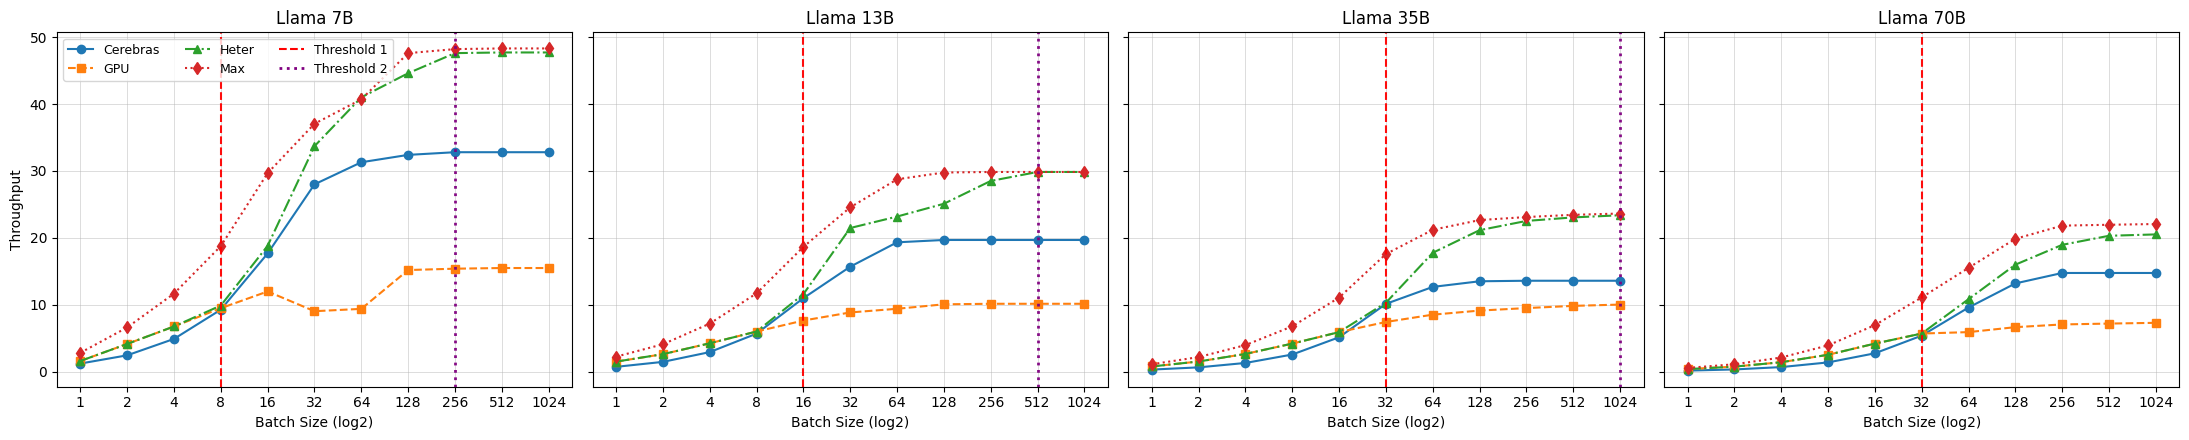

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Batch sizes
x = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024], dtype=float)

# ------------------ Throughput: Set 1 ------------------
cerebras_1 = np.array([1.23, 2.46, 4.91, 9.28, 17.68, 28, 31.3, 32.4, 32.8, 32.8, 32.8], dtype=float)
gpu_1      = np.array([1.61, 4.16, 6.77, 9.5, 12, 9.05, 9.4, 15.2, 15.4, 15.5, 15.5], dtype=float)
heter_1    = np.array([1.61, 4.16, 6.77, 9.9, 18.82, 33.7, 41, 44.6, 47.6, 47.7, 47.7], dtype=float)

# ------------------ Throughput: Set 2 ------------------
cerebras_2 = np.array([0.74, 1.48, 2.94, 5.7, 11, 15.7, 19.34, 19.69, 19.69, 19.69, 19.69], dtype=float)
gpu_2      = np.array([1.51515151515152, 2.63157894736842, 4.25531914893617, 6.01503759398496,
                       7.6555023923445, 8.86426592797784, 9.41176470588235, 10.0787401574803,
                       10.1587301587302, 10.1587301587302, 10.1587301587302], dtype=float)
heter_2    = np.array([1.51515151515152, 2.63157894736842, 4.25531914893617, 6.01503759398496,
                       11.5942028985507, 21.4765100671141, 23.1884057971014, 25.0980392156863,
                       28.5077951002227, 29.85, 29.85], dtype=float)

# ------------------ Throughput: Set 3 ------------------
cerebras_3 = np.array([0.33, 0.66, 1.32, 2.58, 5.16, 10.15, 12.68, 13.52, 13.6, 13.6, 13.6], dtype=float)
gpu_3      = np.array([0.793650793650794, 1.53846153846154, 2.66666666666667, 4.21052631578947,
                       5.92592592592593, 7.44186046511628, 8.53333333333333, 9.14285714285714,
                       9.51672862453532, 9.84615384615385, 10.0392156862745], dtype=float)
heter_3    = np.array([0.793650793650794, 1.53846153846154, 2.66666666666667, 4.21052631578947,
                       5.92592592592593, 10.3225806451613, 17.7777777777778, 21.1570247933884,
                       22.5352112676056, 23.0630630630631, 23.37899543379], dtype=float)

# ------------------ Throughput: Set 4 ------------------
cerebras_4 = np.array([
    0.175438596491228, 0.350877192982456, 0.701754385964912, 1.4,
    2.76, 5.4, 9.6, 13.2,
    14.76, 14.76, 14.76
], dtype=float)
gpu_4      = np.array([0.404858299595142, 0.769230769230769, 1.42857142857143, 2.53968253968254,
                       4.21052631578947, 5.71428571428571, 5.92592592592593, 6.66666666666667,
                       7.07182320441989, 7.20112517580872, 7.31428571428571], dtype=float)
heter_4    = np.array([0.404858299595142, 0.769230769230769, 1.42857142857143, 2.53968253968254,
                       4.21052631578947, 5.71428571428571, 10.8474576271186, 16,
                       18.962962962963, 20.3174603174603, 20.5210420841683], dtype=float)

datasets = [
    ("Llama 7B", cerebras_1, gpu_1, heter_1),
    ("Llama 13B", cerebras_2, gpu_2, heter_2),
    ("Llama 35B", cerebras_3, gpu_3, heter_3),
    ("Llama 70B", cerebras_4, gpu_4, heter_4),
]

# 每个图对应的两条竖线位置
first_lines  = [8, 16, 32, 32]
second_lines = [256, 512, 1024, None]

# 阈值线样式
threshold1_color = 'red'
threshold2_color = 'purple'

fig, axes = plt.subplots(1, 4, figsize=(22, 4.5), sharey=True)

for i, (ax, (title, cerebras, gpu, heter)) in enumerate(zip(axes, datasets)):
    max_tp = cerebras + gpu

    ax.plot(x, cerebras, linestyle='-',  marker='o', label='Cerebras')
    ax.plot(x, gpu,      linestyle='--', marker='s', label='GPU')
    ax.plot(x, heter,    linestyle='-.', marker='^', label='Heter')
    ax.plot(x, max_tp,   linestyle=':',  marker='d', label='Max')

    # Threshold 1
    ax.axvline(
        x=first_lines[i],
        color=threshold1_color,
        linestyle='--',
        linewidth=1.5,
        alpha=0.95
    )

    # Threshold 2
    if second_lines[i] is not None:
        ax.axvline(
            x=second_lines[i],
            color=threshold2_color,
            linestyle=':',
            linewidth=2.0,
            alpha=0.95
        )

    ax.set_xscale('log', base=2)
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(v)) for v in x])
    ax.set_xlabel('Batch Size (log2)')
    ax.set_title(title)
    ax.grid(True, linewidth=0.5, alpha=0.6)

axes[0].set_ylabel('Throughput')

# 手动创建图例项
legend_handles = [
    Line2D([0], [0], linestyle='-',  marker='o', color='C0', label='Cerebras'),
    Line2D([0], [0], linestyle='--', marker='s', color='C1', label='GPU'),
    Line2D([0], [0], linestyle='-.', marker='^', color='C2', label='Heter'),
    Line2D([0], [0], linestyle=':',  marker='d', color='C3', label='Max'),
    Line2D([0], [0], linestyle='--', color=threshold1_color, linewidth=1.5, label='Threshold 1'),
    Line2D([0], [0], linestyle=':',  color=threshold2_color, linewidth=2.0, label='Threshold 2'),
]

axes[0].legend(handles=legend_handles, ncol=3, fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig("/Users/huziyu/Downloads/ddp_throughput.pdf", bbox_inches="tight")
plt.show()

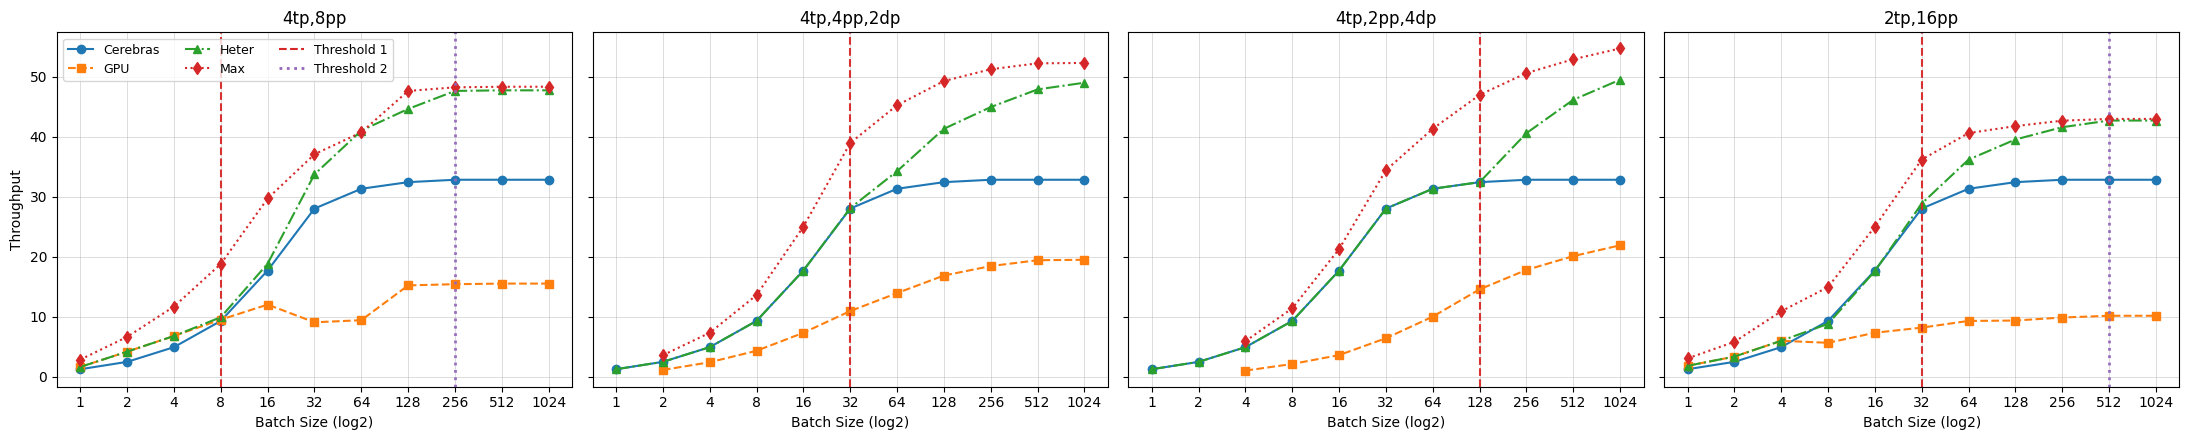

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Batch sizes
x = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024], dtype=float)

# ------------------ Throughput datasets ------------------
cerebras_3 = np.array(
    [1.23, 2.46, 4.91, 9.28, 17.68, 28, 31.3, 32.4, 32.8, 32.8, 32.8],
    dtype=float
)
gpu_3  = np.array([np.nan, np.nan, 1.0, 2.10526315789474, 3.58744394618834, 6.4, 10.0, 14.5454545454545, 17.7777777777778, 20.078431372549, 21.8803418803419], dtype=float)
heter_3 = np.array([1.23, 2.46, 4.91, 9.28, 17.68, 28.0000000000001, 31.3, 32.4, 40.5705229793978, 46.1261261261261, 49.4685990338164], dtype=float)

cerebras_2 = np.array([1.23, 2.46, 4.91, 9.28, 17.68, 28, 31.3, 32.4, 32.8, 32.8, 32.8], dtype=float)
gpu_2      = np.array([np.nan, 1.11111111111111, 2.39520958083832, 4.3010752688172, 7.30593607305936, 10.9215017064846, 13.9130434782609, 16.8421052631579, 18.4172661870504, 19.3939393939394, 19.467680608365], dtype=float)
heter_2    = np.array([1.23, 2.46, 4.91, 9.28, 17.68, 28.0701754385965, 34.2245989304813, 41.2903225806452, 44.9122807017544, 47.8504672897196, 48.9717838354854], dtype=float)

gpu_4       = np.array([1.8018018018018, 3.33333333333333, 5.97014925373134, 5.63380281690141, 7.30593607305936, 8.16326530612245, 9.27536231884058, 9.34306569343066, 9.84615384615385, 10.1386138613861, 10.1386138613861], dtype=float)
cerebras_4 = np.array([1.23, 2.46, 4.91, 9.28, 17.68, 28, 31.3, 32.4, 32.8, 32.8, 32.8], dtype=float)
heter_4    = np.array([1.8018018018018, 3.33333333333333, 5.97014925373134, 8.79120879120879, 17.5824175824176, 28.8288288288288, 36.1581920903955, 39.5061728395062, 41.5584415584416, 42.6666666666667, 42.6666666666667], dtype=float)

cerebras_1 = np.array([1.23, 2.46, 4.91, 9.28, 17.68, 28, 31.3, 32.4, 32.8, 32.8, 32.8], dtype=float)
gpu_1      = np.array([1.61, 4.16, 6.77, 9.5, 12, 9.05, 9.4, 15.2, 15.4, 15.5, 15.5], dtype=float)
heter_1    = np.array([1.61, 4.16, 6.77, 9.9, 18.82, 33.7, 41, 44.6, 47.6, 47.7, 47.7], dtype=float)

datasets = [
    ("4tp,8pp",     cerebras_1, gpu_1, heter_1),
    ("4tp,4pp,2dp", cerebras_2, gpu_2, heter_2),
    ("4tp,2pp,4dp", cerebras_3, gpu_3, heter_3),
    ("2tp,16pp",    cerebras_4, gpu_4, heter_4),
]

# =========================================================
# 在这里填每个子图的两条竖线位置
# 比如 [8, 16, 32, 8] 这种
# 如果某个图没有第二条线，就填 None
# =========================================================
first_lines  = [8, 32, 128, 32]
second_lines = [256, None, None, 512]

# 阈值线样式
threshold1_color = '#d62728'   # 深红
threshold2_color = '#9467bd'   # 紫色

fig, axes = plt.subplots(1, 4, figsize=(22, 4.5), sharey=True)

for i, (ax, (title, cerebras, gpu, heter)) in enumerate(zip(axes, datasets)):
    max_tp = cerebras + gpu

    ax.plot(x, cerebras, linestyle='-',  marker='o', label='Cerebras')
    ax.plot(x, gpu,      linestyle='--', marker='s', label='GPU')
    ax.plot(x, heter,    linestyle='-.', marker='^', label='Heter')
    ax.plot(x, max_tp,   linestyle=':',  marker='d', label='Max')

    # Threshold 1
    if first_lines[i] is not None:
        ax.axvline(
            x=first_lines[i],
            color=threshold1_color,
            linestyle='--',
            linewidth=1.5,
            alpha=0.95
        )

    # Threshold 2
    if second_lines[i] is not None:
        ax.axvline(
            x=second_lines[i],
            color=threshold2_color,
            linestyle=':',
            linewidth=2.0,
            alpha=0.95
        )

    ax.set_xscale('log', base=2)
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(v)) for v in x])
    ax.set_xlabel('Batch Size (log2)')
    ax.set_title(title)
    ax.grid(True, linewidth=0.5, alpha=0.6)

axes[0].set_ylabel('Throughput')

# 手动创建图例项
legend_handles = [
    Line2D([0], [0], linestyle='-',  marker='o', color='C0', label='Cerebras'),
    Line2D([0], [0], linestyle='--', marker='s', color='C1', label='GPU'),
    Line2D([0], [0], linestyle='-.', marker='^', color='C2', label='Heter'),
    Line2D([0], [0], linestyle=':',  marker='d', color='C3', label='Max'),
    Line2D([0], [0], linestyle='--', color=threshold1_color, linewidth=1.5, label='Threshold 1'),
    Line2D([0], [0], linestyle=':',  color=threshold2_color, linewidth=2.0, label='Threshold 2'),
]

axes[0].legend(handles=legend_handles, ncol=3, fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig("/Users/huziyu/Downloads/para_throughput.pdf", bbox_inches="tight")
plt.show()

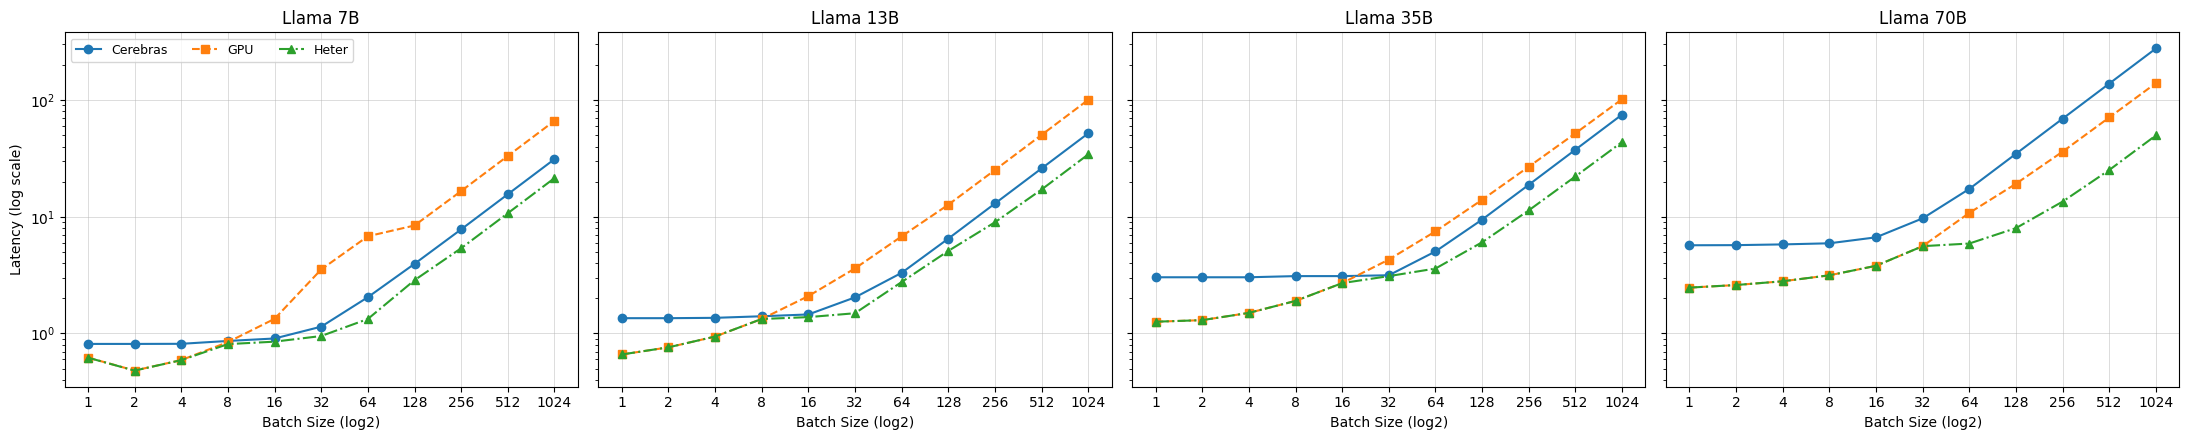

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Batch sizes
x = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024], dtype=float)

# ---------- Dataset 1 (你最开始给的那组) ----------
cerebras_1 = np.array([
    0.813008130081301, 0.813008130081301, 0.814663951120163, 0.862068965517241,
    0.904977375565611, 1.14285714285714, 2.04472843450479, 3.95061728395062,
    7.80487804878049, 15.609756097561, 31.219512195122
], dtype=float)

gpu_1 = np.array([
    0.62111801242236, 0.480769230769231, 0.590841949778434, 0.842105263157895,
    1.33333333333333, 3.53591160220994, 6.80851063829787, 8.42105263157895,
    16.6233766233766, 33.2467532467532, 66.4935064935064
], dtype=float)

heter_1 = np.array([
    0.62, 0.48, 0.59, 0.81, 0.85, 0.95, 1.33, 2.86, 5.3781512605042,
    10.7337526205451, 21.4675052410901
], dtype=float)

# ---------- Dataset 2 ----------
cerebras_2 = np.array([
    1.35135135135135, 1.35135135135135, 1.36054421768707, 1.40350877192982,
    1.45454545454545, 2.03821656050955, 3.30920372285419, 6.50076180802438,
    13.0015236160488, 26.0030472320976, 52.0060944641952
], dtype=float)

gpu_2 = np.array([
    0.66, 0.76, 0.94, 1.33,
    2.09, 3.61, 6.8, 12.7,
    25.2, 50.4, 100.8
], dtype=float)

heter_2 = np.array([
    0.66, 0.76, 0.94, 1.33, 1.38,
    1.49, 2.76, 5.1, 8.98,
    17.1524288107203, 34.3048576214405
], dtype=float)

# ---------- Dataset 3 ----------
cerebras_3 = np.array([
    3.03030303030303, 3.03030303030303, 3.03030303030303, 3.10077519379845,
    3.10077519379845, 3.15270935960591, 5.04731861198738, 9.46745562130178,
    18.8235294117647, 37.6470588235294, 75.2941176470588
], dtype=float)

gpu_3 = np.array([
    1.26, 1.3, 1.5, 1.9,
    2.7, 4.3, 7.5, 14,
    26.9, 52, 102
], dtype=float)

heter_3 = np.array([
    1.26, 1.3, 1.5, 1.9, 2.7,
    3.1, 3.6, 6.05, 11.36,
    22.2, 43.8
], dtype=float)

# ---------- Dataset 4 ----------
cerebras_4 = np.array([
    5.7, 5.71428571428571, 5.79710144927536, 5.92592592592593,
    6.66666666666667, 9.6969696969697, 17.3441734417344, 34.6883468834688,
    69.3766937669376, 138.753387533875, 277.50677506775
], dtype=float)

gpu_4 = np.array([
    2.47, 2.6, 2.8, 3.15,
    3.8, 5.6, 10.8, 19.2,
    36.2, 71.1, 140
], dtype=float)

heter_4 = np.array([
    2.47, 2.6, 2.8, 3.15, 3.8,
    5.6, 5.9, 8, 13.5,
    25.2, 49.9
], dtype=float)

datasets = [
    ("Llama 7B", cerebras_1, gpu_1, heter_1),
    ("Llama 13B", cerebras_2, gpu_2, heter_2),
    ("Llama 35B", cerebras_3, gpu_3, heter_3),
    ("Llama 70B", cerebras_4, gpu_4, heter_4),
]

# 4 张图横排，y 轴对齐（sharey=True）
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5), sharey=True)

for ax, (title, cerebras, gpu, heter) in zip(axes, datasets):
    ax.plot(x, cerebras, linestyle='-',  marker='o', label='Cerebras')
    ax.plot(x, gpu,      linestyle='--', marker='s', label='GPU')
    ax.plot(x, heter,    linestyle='-.', marker='^', label='Heter')

    ax.set_xscale('log', base=2)   # log2 x-axis
    ax.set_yscale('log')           # log y-axis
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(v)) for v in x])

    ax.set_xlabel('Batch Size (log2)')
    ax.set_title(title)
    ax.grid(True, linewidth=0.5, alpha=0.6)

axes[0].set_ylabel('Latency (log scale)')
axes[0].legend(ncol=3, fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig("/Users/huziyu/Downloads/latency.pdf", bbox_inches="tight")
plt.show()

# 可选保存
# plt.savefig('latency_4sets_1x4_sharey.png', dpi=300, bbox_inches='tight')

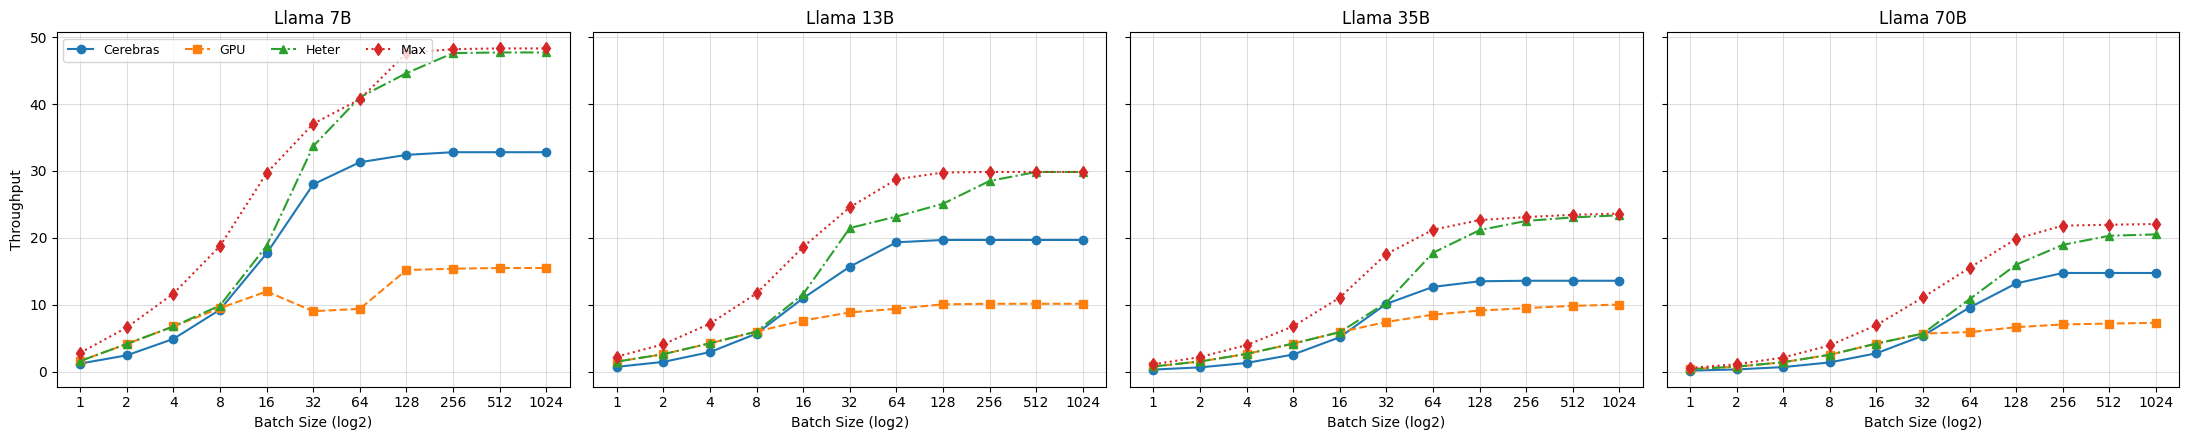

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Batch sizes
x = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024], dtype=float)

# ------------------ Throughput: Set 1 ------------------
cerebras_1 = np.array([1.23, 2.46, 4.91, 9.28, 17.68, 28, 31.3, 32.4, 32.8, 32.8, 32.8], dtype=float)
gpu_1      = np.array([1.61, 4.16, 6.77, 9.5, 12, 9.05, 9.4, 15.2, 15.4, 15.5, 15.5], dtype=float)
heter_1    = np.array([1.61, 4.16, 6.77, 9.9, 18.82, 33.7, 41, 44.6, 47.6, 47.7, 47.7], dtype=float)

# ------------------ Throughput: Set 2 ------------------
cerebras_2 = np.array([0.74, 1.48, 2.94, 5.7, 11, 15.7, 19.34, 19.69, 19.69, 19.69, 19.69], dtype=float)
gpu_2      = np.array([1.51515151515152, 2.63157894736842, 4.25531914893617, 6.01503759398496,
                       7.6555023923445, 8.86426592797784, 9.41176470588235, 10.0787401574803,
                       10.1587301587302, 10.1587301587302, 10.1587301587302], dtype=float)
heter_2    = np.array([1.51515151515152, 2.63157894736842, 4.25531914893617, 6.01503759398496,
                       11.5942028985507, 21.4765100671141, 23.1884057971014, 25.0980392156863,
                       28.5077951002227, 29.85, 29.85], dtype=float)

# ------------------ Throughput: Set 3 ------------------
cerebras_3 = np.array([0.33, 0.66, 1.32, 2.58, 5.16, 10.15, 12.68, 13.52, 13.6, 13.6, 13.6], dtype=float)
gpu_3      = np.array([0.793650793650794, 1.53846153846154, 2.66666666666667, 4.21052631578947,
                       5.92592592592593, 7.44186046511628, 8.53333333333333, 9.14285714285714,
                       9.51672862453532, 9.84615384615385, 10.0392156862745], dtype=float)
heter_3    = np.array([0.793650793650794, 1.53846153846154, 2.66666666666667, 4.21052631578947,
                       5.92592592592593, 10.3225806451613, 17.7777777777778, 21.1570247933884,
                       22.5352112676056, 23.0630630630631, 23.37899543379], dtype=float)

# ------------------ Throughput: Set 4 ------------------
cerebras_4 = np.array([
    0.175438596491228, 0.350877192982456, 0.701754385964912, 1.4,
    2.76, 5.4, 9.6, 13.2,
    14.76, 14.76, 14.76
], dtype=float)
gpu_4      = np.array([0.404858299595142, 0.769230769230769, 1.42857142857143, 2.53968253968254,
                       4.21052631578947, 5.71428571428571, 5.92592592592593, 6.66666666666667,
                       7.07182320441989, 7.20112517580872, 7.31428571428571], dtype=float)
heter_4    = np.array([0.404858299595142, 0.769230769230769, 1.42857142857143, 2.53968253968254,
                       4.21052631578947, 5.71428571428571, 10.8474576271186, 16,
                       18.962962962963, 20.3174603174603, 20.5210420841683], dtype=float)

datasets = [
    ("Llama 7B", cerebras_1, gpu_1, heter_1),
    ("Llama 13B", cerebras_2, gpu_2, heter_2),
    ("Llama 35B", cerebras_3, gpu_3, heter_3),
    ("Llama 70B", cerebras_4, gpu_4, heter_4),
]

# 4张图横排，纵坐标对齐
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5), sharey=True)

for ax, (title, cerebras, gpu, heter) in zip(axes, datasets):
    # 最大吞吐量：理论上如果两边完全并行、无额外开销，则上界是相加
    max_tp = cerebras + gpu

    ax.plot(x, cerebras, linestyle='-',  marker='o', label='Cerebras')
    ax.plot(x, gpu,      linestyle='--', marker='s', label='GPU')
    ax.plot(x, heter,    linestyle='-.', marker='^', label='Heter')
    ax.plot(x, max_tp,   linestyle=':',  marker='d', label='Max')  # ✅新增这条线

    ax.set_xscale('log', base=2)
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(v)) for v in x])
    ax.set_xlabel('Batch Size (log2)')
    ax.set_title(title)
    ax.grid(True, linewidth=0.5, alpha=0.6)

axes[0].set_ylabel('Throughput')
axes[0].legend(ncol=4, fontsize=9, loc='upper left')  # 现在4条线了

plt.tight_layout()
plt.savefig("/Users/huziyu/Downloads/dp_throughput.pdf", bbox_inches="tight")
plt.show()

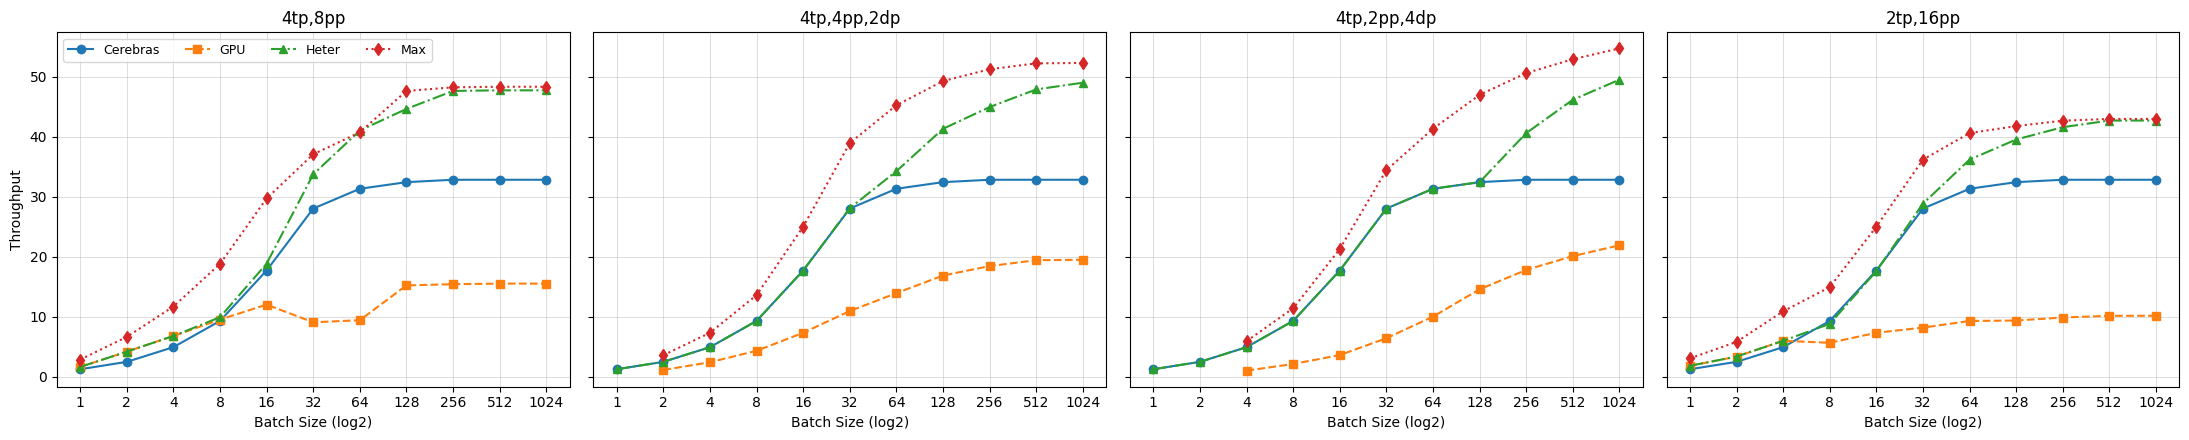

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Batch sizes
x = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024], dtype=float)

# ------------------ Throughput: Set 1 ------------------

cerebras_3 = np.array(
    [1.23, 2.46, 4.91, 9.28, 17.68, 28, 31.3, 32.4, 32.8, 32.8, 32.8],
    dtype=float
)

gpu_3  = np.array([np.nan, np.nan, 1.0, 2.10526315789474, 3.58744394618834, 6.4, 10.0, 14.5454545454545, 17.7777777777778, 20.078431372549, 21.8803418803419], dtype=float)
heter_3 = np.array([1.23, 2.46, 4.91, 9.28, 17.68, 28.0000000000001, 31.3, 32.4, 40.5705229793978, 46.1261261261261, 49.4685990338164], dtype=float)

cerebras_2 = np.array([1.23, 2.46, 4.91, 9.28, 17.68, 28, 31.3, 32.4, 32.8, 32.8, 32.8], dtype=float)
gpu_2      = np.array([np.nan, 1.11111111111111, 2.39520958083832, 4.3010752688172, 7.30593607305936, 10.9215017064846, 13.9130434782609, 16.8421052631579, 18.4172661870504, 19.3939393939394, 19.467680608365], dtype=float)
heter_2    = np.array([1.23, 2.46, 4.91, 9.28, 17.68, 28.0701754385965, 34.2245989304813, 41.2903225806452, 44.9122807017544, 47.8504672897196, 48.9717838354854], dtype=float)
# ------------------ Throughput: Set 4 ------------------

gpu_4       = np.array([1.8018018018018, 3.33333333333333, 5.97014925373134, 5.63380281690141, 7.30593607305936, 8.16326530612245, 9.27536231884058, 9.34306569343066, 9.84615384615385, 10.1386138613861, 10.1386138613861], dtype=float)

cerebras_4 = np.array([1.23, 2.46, 4.91, 9.28, 17.68, 28, 31.3, 32.4, 32.8, 32.8, 32.8], dtype=float)

heter_4    = np.array([1.8018018018018, 3.33333333333333, 5.97014925373134, 8.79120879120879, 17.5824175824176, 28.8288288288288, 36.1581920903955, 39.5061728395062, 41.5584415584416, 42.6666666666667, 42.6666666666667], dtype=float)


cerebras_1 = np.array([1.23, 2.46, 4.91, 9.28, 17.68, 28, 31.3, 32.4, 32.8, 32.8, 32.8], dtype=float)
gpu_1      = np.array([1.61, 4.16, 6.77, 9.5, 12, 9.05, 9.4, 15.2, 15.4, 15.5, 15.5], dtype=float)
heter_1    = np.array([1.61, 4.16, 6.77, 9.9, 18.82, 33.7, 41, 44.6, 47.6, 47.7, 47.7], dtype=float)

datasets = [
    ("4tp,8pp", cerebras_1, gpu_1, heter_1),
    ("4tp,4pp,2dp", cerebras_2, gpu_2, heter_2),
    ("4tp,2pp,4dp", cerebras_3, gpu_3, heter_3),
    ("2tp,16pp", cerebras_4, gpu_4, heter_4),
    
]

# 4张图横排，纵坐标对齐
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5), sharey=True)

for ax, (title, cerebras, gpu, heter) in zip(axes, datasets):
    # 最大吞吐量：理论上如果两边完全并行、无额外开销，则上界是相加

    max_tp = cerebras + gpu

    ax.plot(x, cerebras, linestyle='-',  marker='o', label='Cerebras')
    ax.plot(x, gpu,      linestyle='--', marker='s', label='GPU')
    ax.plot(x, heter,    linestyle='-.', marker='^', label='Heter')
    ax.plot(x, max_tp,   linestyle=':',  marker='d', label='Max')  # ✅新增这条线

    ax.set_xscale('log', base=2)
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(v)) for v in x])
    ax.set_xlabel('Batch Size (log2)')
    ax.set_title(title)
    ax.grid(True, linewidth=0.5, alpha=0.6)

axes[0].set_ylabel('Throughput')
axes[0].legend(ncol=4, fontsize=9, loc='upper left')  # 现在4条线了

plt.tight_layout()
plt.savefig("/Users/huziyu/Downloads/ddp_throughput.pdf", bbox_inches="tight")
plt.show()

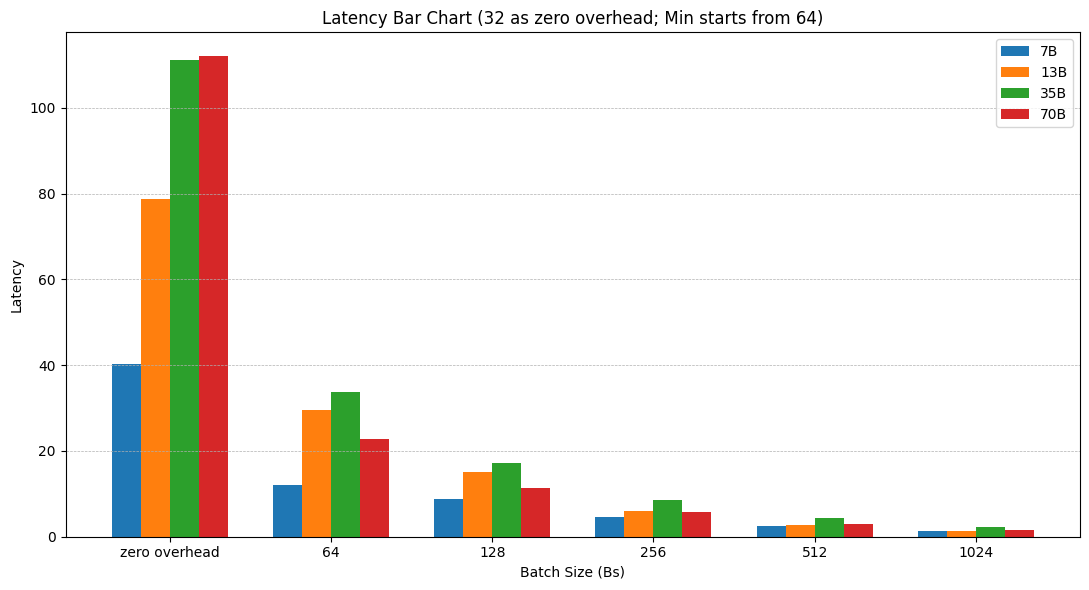

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# X axis: remove <32; rename 32 to "zero overhead"
cats = ["zero overhead", "64", "128", "256", "512", "1024"]
x = np.arange(len(cats))

# Perfect values (shown only at "zero overhead")
perfect = np.array([
    40.3225806451613,
    78.7878787878788,
    111.111111111111,
    112.0
], dtype=float)

# Min values start from 64 (64,128,256,512,1024)
min_vals = np.array([
    [11.9648318042814,  8.79899191796296, 4.53436301818503, 2.40107407826109, 1.23983251122448],
    [29.5722132699749, 15.0222866482583,  5.97491873975123, 2.83205322415518, 1.44194212669595],
    [33.6972862978543, 17.2948159410543,  8.64888436659642, 4.35403022209213, 2.17904817710718],
    [22.7642276422764, 11.2449799196787,  5.8455114822547,  2.96924708377519, 1.53256704980843],
], dtype=float)

# Build 4 series across 6 categories:
# index 0 is Perfect; indices 1..5 are Min at 64..1024
series = []
for i in range(4):
    s = np.empty(6, dtype=float)
    s[:] = np.nan
    s[0] = perfect[i]
    s[1:] = min_vals[i]
    series.append(s)

plt.figure(figsize=(11, 6))

# Grouped bar chart
width = 0.18
offsets = (-1.5*width, -0.5*width, 0.5*width, 1.5*width)

labels = ["7B", "13B", "35B", "70B"]

for i, s in enumerate(series):
    plt.bar(x + offsets[i], s, width=width, label=labels[i])

plt.xticks(x, cats)
plt.xlabel("Batch Size (Bs)")
plt.ylabel("Latency")
plt.title("Latency Bar Chart (32 as zero overhead; Min starts from 64)")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

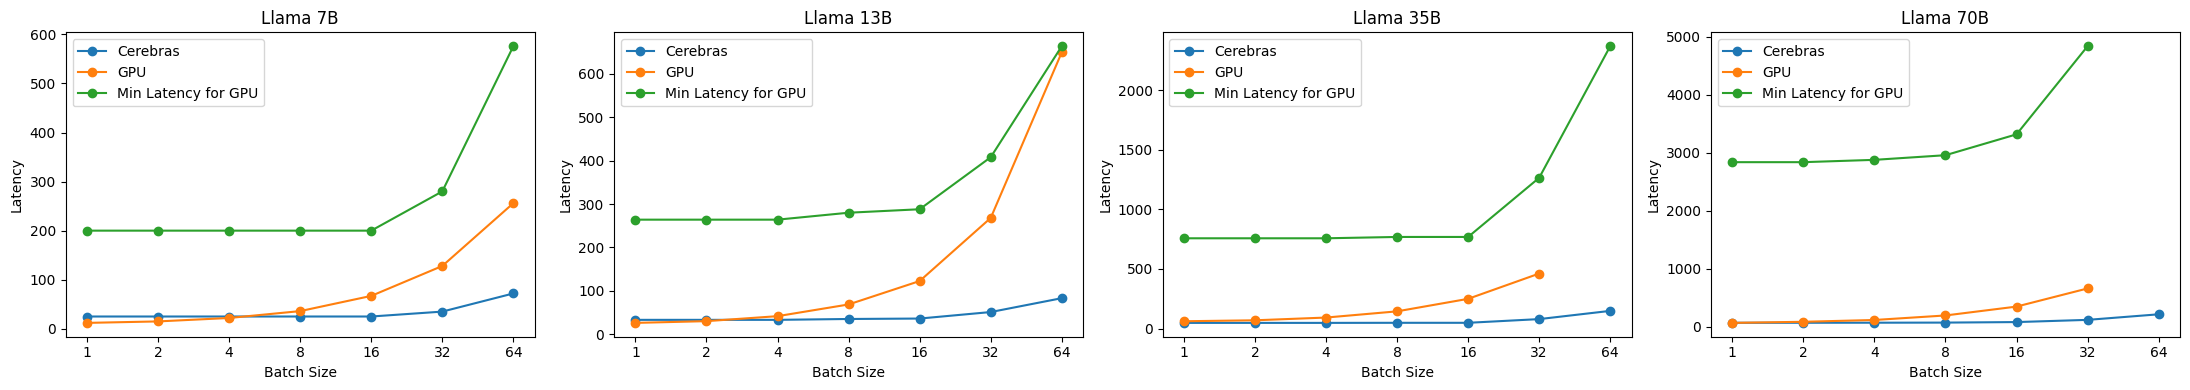

In [32]:
import matplotlib.pyplot as plt

batch_sizes = [1, 2, 4, 8, 16, 32, 64]

# 4 groups of data
groups = [
    {
        "title": "Llama 7B",
        "cerebras": [25, 25, 25, 25, 25, 35, 72],
        "gpu":      [12, 15, 22, 36, 67, 128, 256],
        "min":      [200, 200, 200, 200, 200, 280, 576],
    },
    {
        "title": "Llama 13B",
        "cerebras": [33, 33, 33, 35, 36, 51, 83],
        "gpu":      [26, 30, 41.5, 68.5, 122.5, 268, 650],
        "min":      [264, 264, 264, 280, 288, 408, 664],
    },
    {
        "title": "Llama 35B",
        "cerebras": [47.3, 47.3, 47.3, 48, 48, 79, 148],
        "gpu":      [61, 69, 92, 144, 249, 461, None],   # missing at 64
        "min":      [756.8, 756.8, 756.8, 768, 768, 1264, 2368],
    },
    {
        "title": "Llama 70B",
        "cerebras": [71, 71, 72, 74, 83, 121, 217],
        "gpu":      [69, 88, 119, 197, 350, 663, None],   # missing at 64
        "min":      [2840, 2840, 2880, 2960, 3320, 4840, None],  # missing at 64
    },
]

def plot_series(ax, x, y, label):
    # Skip None values (e.g., missing data at batch_size=64)
    xf, yf = zip(*[(xi, yi) for xi, yi in zip(x, y) if yi is not None])
    ax.plot(xf, yf, marker="o", label=label)

fig, axes = plt.subplots(1, 4, figsize=(22, 4), sharex=True)

for ax, g in zip(axes, groups):
    plot_series(ax, batch_sizes, g["cerebras"], "Cerebras")
    plot_series(ax, batch_sizes, g["gpu"], "GPU")
    plot_series(ax, batch_sizes, g["min"], "Min Latency for GPU")

    ax.set_xscale("log", base=2)
    ax.set_xticks(batch_sizes)
    ax.set_xticklabels([str(b) for b in batch_sizes])

    ax.set_title(g["title"])
    ax.set_xlabel("Batch Size")
    ax.set_ylabel("Latency")
    ax.legend()

plt.tight_layout()
plt.savefig("/Users/huziyu/Downloads/pp_latency.pdf", bbox_inches="tight")
plt.show()

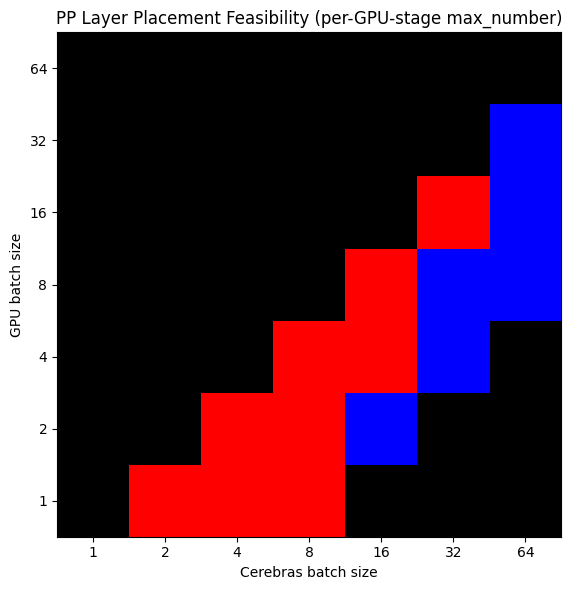

Blue cells (violations):
  GPU=2, Cerebras=16: stages=(22,), max_stage=22 > limit=16
  GPU=4, Cerebras=32: stages=(20,), max_stage=20 > limit=16
  GPU=8, Cerebras=32: stages=(11, 11), max_stage=11 > limit=8
  GPU=8, Cerebras=64: stages=(22,), max_stage=22 > limit=8
  GPU=16, Cerebras=64: stages=(11, 11), max_stage=11 > limit=8
  GPU=32, Cerebras=64: stages=(6, 6, 6, 6), max_stage=6 > limit=4


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# -----------------------------
# Inputs from your table
# -----------------------------
gpu_bs = [1, 2, 4, 8, 16, 32, 64]
cer_bs = [1, 2, 4, 8, 16, 32, 64]

# Max_number means:
# when GPU batchsize = g, EACH GPU stage's layer count must be <= max_number_by_gpu[g]
max_number_by_gpu = {
    1: 32,
    2: 16,
    4: 16,
    8: 8,
    16: 8,
    32: 4,
    64: 4,
}

# (gpu_bs, cerebras_bs) -> tuple of per-stage layer counts, or "X" (infeasible)
assignments = {
    (1, 1): "X",
    (1, 2): (8, 7, 7, 7),
    (1, 4): (13, 13),
    (1, 8): (22,),

    (2, 2): "X",
    (2, 4): (7, 7, 7, 7),
    (2, 8): (13, 13),
    (2, 16): (22,),

    (4, 4): "X",
    (4, 8): (7, 7, 6, 6),
    (4, 16): (11, 11),
    (4, 32): (20,),

    (8, 8): "X",
    (8, 16): (6, 6, 6, 6),
    (8, 32): (11, 11),
    (8, 64): (22,),

    (16, 16): "X",
    (16, 32): (6, 6, 6, 6),
    (16, 64): (11, 11),

    (32, 32): "X",
    (32, 64): (6, 6, 6, 6),

    (64, 64): "X",
}

# -----------------------------
# Build classification grid
# 0 = black  (infeasible: "X" or empty)
# 1 = blue   (has assignment but violates max_number_by_gpu[g])
# 2 = red    (feasible)
# -----------------------------
grid = np.zeros((len(gpu_bs), len(cer_bs)), dtype=int)

for i, g in enumerate(gpu_bs):
    for j, c in enumerate(cer_bs):
        key = (g, c)
        if key not in assignments:
            grid[i, j] = 0
            continue

        val = assignments[key]
        if val == "X":
            grid[i, j] = 0
            continue

        limit = max_number_by_gpu[g]
        # Blue if ANY stage exceeds the per-stage limit for this GPU batch size
        grid[i, j] = 1 if any(x > limit for x in val) else 2

# -----------------------------
# Plot
# -----------------------------
cmap = ListedColormap(["black", "blue", "red"])

plt.figure(figsize=(9, 6))
plt.imshow(grid, cmap=cmap, interpolation="nearest")

plt.xticks(range(len(cer_bs)), cer_bs)
plt.yticks(range(len(gpu_bs)), gpu_bs)
plt.xlabel("Cerebras batch size")
plt.ylabel("GPU batch size")
plt.title("PP Layer Placement Feasibility (per-GPU-stage max_number)")

# Optional: flip y so small GPU BS appears at bottom (comment out if you prefer default)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# -----------------------------
# Optional: print which cells are blue and why
# -----------------------------
print("Blue cells (violations):")
for g in gpu_bs:
    for c in cer_bs:
        key = (g, c)
        if key in assignments and assignments[key] != "X":
            val = assignments[key]
            limit = max_number_by_gpu[g]
            vmax = max(val)
            if vmax > limit:
                print(f"  GPU={g}, Cerebras={c}: stages={val}, max_stage={vmax} > limit={limit}")

In [139]:
import numpy as np import matplotlib.pyplot as plt from matplotlib.colors import ListedColormap from matplotlib.patches import Patch gpu_bs = [1, 2, 4, 8, 16, 32, 64] cer_bs = [1, 2, 4, 8, 16, 32, 64] # 左图: Upper 13B, Lower 7B combined_visual_left = np.array([ [0, 0, 0, 1, 1, 1, -1], [0, 0, 1, 1, 1, -1, 1], [0, 1, 1, 2, -1, 2, 1], [1, 1, 2, -1, 2, 1, 1], [2, 2, -1, 2, 2, 1, 0], [2, -1, 2, 2, 1, 0, 0], [-1, 2, 2, 2, 0, 0, 0], ], dtype=int) # 右图: Upper 70B, Lower 35B combined_visual_right = np.array([ [0, 0, 0, 0, 1, 1, -1], [0, 0, 0, 1, 1, -1, 1], [0, 0, 1, 1, -1, 1, 1], [0, 1, 1, -1, 1, 1, 1], [1, 1, -1, 1, 1, 1, 1], [2, -1, 2, 1, 1, 1, 0], [-1, 2, 2, 1, 1, 0, 0], ], dtype=int) cmap = ListedColormap(["white", "black", "blue", "red"]) def draw_map(ax, combined_visual, title, upper_text, lower_text, show_ylabel=True, upper_pos=(4.8, 1.0), lower_pos=(1.0, 4.8)): combined = np.flipud(combined_visual) display_grid = combined + 1 ax.imshow(display_grid, cmap=cmap, interpolation="nearest", origin="lower") ax.set_xticks(range(len(cer_bs))) ax.set_yticks(range(len(gpu_bs))) ax.set_xticklabels(cer_bs) if show_ylabel: ax.set_yticklabels(gpu_bs) ax.set_ylabel("Cerebras batch size") else: ax.set_yticklabels([]) ax.tick_params(axis="y", which="both", left=False) ax.set_xlabel("GPU batch size") ax.set_title(title, fontsize=12) ax.set_xticks(np.arange(-0.5, len(cer_bs), 1), minor=True) ax.set_yticks(np.arange(-0.5, len(gpu_bs), 1), minor=True) ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.8, alpha=0.4) ax.tick_params(which="minor", bottom=False, left=False) ax.plot( [-0.5, len(cer_bs) - 0.5], [-0.5, len(gpu_bs) - 0.5], color="gray", linewidth=2 ) ax.text(*upper_pos, upper_text, fontsize=14, weight="bold", color="black") ax.text(*lower_pos, lower_text, fontsize=14, weight="bold", color="black") fig, axes = plt.subplots( 1, 2, figsize=(10.5, 5.2), gridspec_kw={"wspace": 0.05} ) draw_map( axes[0], combined_visual_left, "(a) Upper: 13B, Lower: 7B", "13B", "7B", show_ylabel=True ) draw_map( axes[1], combined_visual_right, "(b) Upper: 70B, Lower: 35B", "", "", show_ylabel=False ) legend_elements = [ Patch(facecolor="red", edgecolor="black", label="Feasible"), Patch(facecolor="blue", edgecolor="black", label="Violation"), Patch(facecolor="black", edgecolor="black", label="Infeasible"), Patch(facecolor="white", edgecolor="black", label="Diagonal / blank"), ] fig.legend( handles=legend_elements, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.01) ) plt.subplots_adjust(bottom=0.22, wspace=0.05) plt.savefig("/Users/huziyu/Downloads/pp_feas_merged.pdf", bbox_inches="tight") plt.show()

SyntaxError: invalid syntax (2104833362.py, line 1)

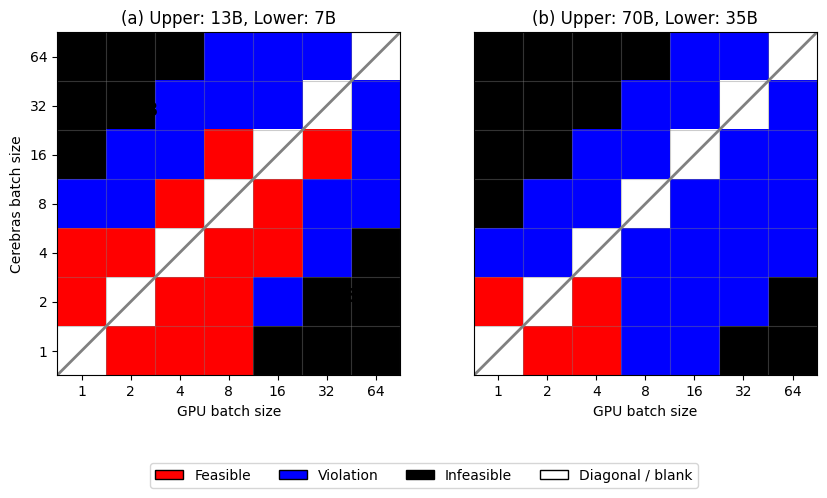

In [131]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

gpu_bs = [1, 2, 4, 8, 16, 32, 64]
cer_bs = [1, 2, 4, 8, 16, 32, 64]

# 左图: Upper 13B, Lower 7B
combined_visual_left = np.array([
    [0, 0, 0, 1, 1, 1, -1],
    [0, 0, 1, 1, 1, -1, 1],
    [0, 1, 1, 2, -1, 2, 1],
    [1, 1, 2, -1, 2, 1, 1],
    [2, 2, -1, 2, 2, 1, 0],
    [2, -1, 2, 2, 1, 0, 0],
    [-1, 2, 2, 2, 0, 0, 0],
], dtype=int)

# 右图: Upper 70B, Lower 35B
combined_visual_right = np.array([
    [0, 0, 0, 0, 1, 1, -1],
    [0, 0, 0, 1, 1, -1, 1],
    [0, 0, 1, 1, -1, 1, 1],
    [0, 1, 1, -1, 1, 1, 1],
    [1, 1, -1, 1, 1, 1, 1],
    [2, -1, 2, 1, 1, 1, 0],
    [-1, 2, 2, 1, 1, 0, 0],
], dtype=int)

cmap = ListedColormap(["white", "black", "blue", "red"])

def draw_map(ax, combined_visual, title, upper_text, lower_text,
             show_ylabel=True,
             upper_pos=(4.8, 1.0), lower_pos=(1.0, 4.8)):
    combined = np.flipud(combined_visual)
    display_grid = combined + 1

    ax.imshow(display_grid, cmap=cmap, interpolation="nearest", origin="lower")

    ax.set_xticks(range(len(cer_bs)))
    ax.set_yticks(range(len(gpu_bs)))
    ax.set_xticklabels(cer_bs)

    if show_ylabel:
        ax.set_yticklabels(gpu_bs)
        ax.set_ylabel("Cerebras batch size")
    else:
        ax.set_yticklabels([])
        ax.tick_params(axis="y", which="both", left=False)

    ax.set_xlabel("GPU batch size")
    ax.set_title(title, fontsize=12)

    ax.set_xticks(np.arange(-0.5, len(cer_bs), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(gpu_bs), 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.8, alpha=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.plot(
        [-0.5, len(cer_bs) - 0.5],
        [-0.5, len(gpu_bs) - 0.5],
        color="gray",
        linewidth=2
    )

    ax.text(*upper_pos, upper_text, fontsize=14, weight="bold", color="black")
    ax.text(*lower_pos, lower_text, fontsize=14, weight="bold", color="black")


fig, axes = plt.subplots(
    1, 2,
    figsize=(10.5, 5.2),
    gridspec_kw={"wspace": 0.05}
)

draw_map(
    axes[0],
    combined_visual_left,
    "(a) Upper: 13B, Lower: 7B",
    "13B",
    "7B",
    show_ylabel=True
)

draw_map(
    axes[1],
    combined_visual_right,
    "(b) Upper: 70B, Lower: 35B",
    "",
    "",
    show_ylabel=False
)

legend_elements = [
    Patch(facecolor="red", edgecolor="black", label="Feasible"),
    Patch(facecolor="blue", edgecolor="black", label="Violation"),
    Patch(facecolor="black", edgecolor="black", label="Infeasible"),
    Patch(facecolor="white", edgecolor="black", label="Diagonal / blank"),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.01)
)

plt.subplots_adjust(bottom=0.22, wspace=0.05)
plt.savefig("/Users/huziyu/Downloads/pp_feas_merged.pdf", bbox_inches="tight")
plt.show()

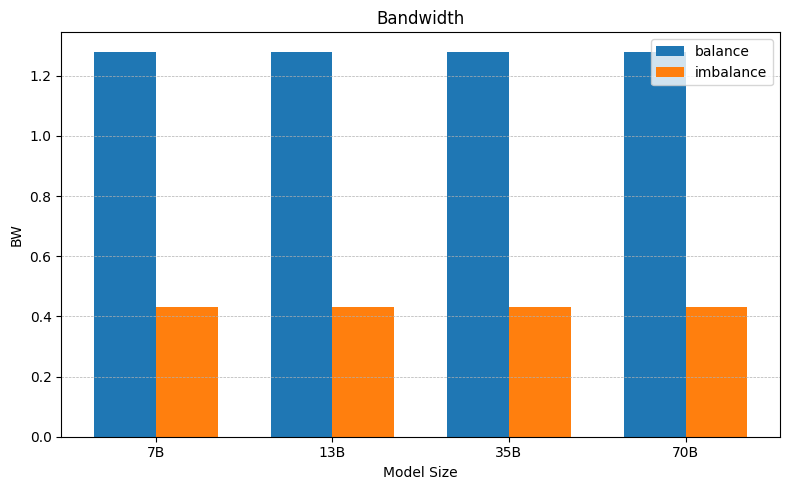

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

models = ["7B", "13B", "35B", "70B"]
x = np.arange(len(models))
#随着lane的数量增多和microbatchsize的增大，需要的带宽更高
# two groups per model: (13, 40)
group1 = [2.56, 2.56, 2.56, 2.56]
group2 = [0.86, 0.86, 0.86, 0.86]

width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, group1, width=width, label="balance")
plt.bar(x + width/2, group2, width=width, label="imbalance")

plt.xticks(x, models)
plt.xlabel("Model Size")
plt.ylabel("BW")
plt.title("Bandwidth")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

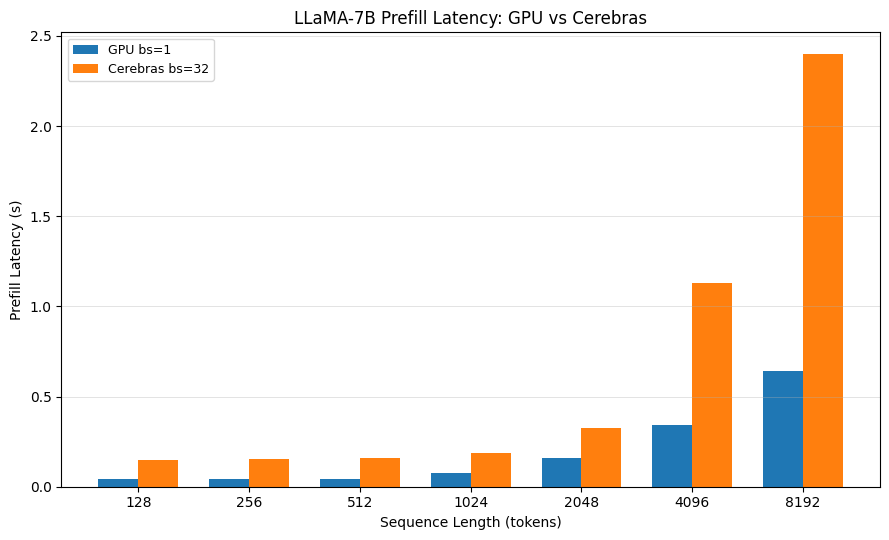

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# X axis
seq = [128, 256, 512, 1024, 2048, 4096, 8192]

# GPU data (seconds)
gpu = {
    1: [0.044, 0.044, 0.044, 0.078, 0.162, 0.340, 0.64]
}
gpu_df = pd.DataFrame(gpu, index=seq)

# Cerebras data (seconds)
cerebras = {
    32: [0.147874306839187, 0.151658767772512, 0.16, 0.184971098265896, 0.32520325203252, 1.13, 2.4]
}
cs_df = pd.DataFrame(cerebras, index=seq)

# Bar positions
x = np.arange(len(seq))
width = 0.36

plt.figure(figsize=(9, 5.5))

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

plt.bar(
    x - width/2,
    gpu_df[1],
    width=width,
    label="GPU bs=1",
    color=colors[0]
)

plt.bar(
    x + width/2,
    cs_df[32],
    width=width,
    label="Cerebras bs=32",
    color=colors[1]
)

plt.xlabel("Sequence Length (tokens)")
plt.ylabel("Prefill Latency (s)")
plt.title("LLaMA-7B Prefill Latency: GPU vs Cerebras")
plt.xticks(x, seq)
plt.grid(True, axis="y", linewidth=0.5, alpha=0.5)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Optional: save
# plt.savefig("llama7b_prefill_bar.png", dpi=200)

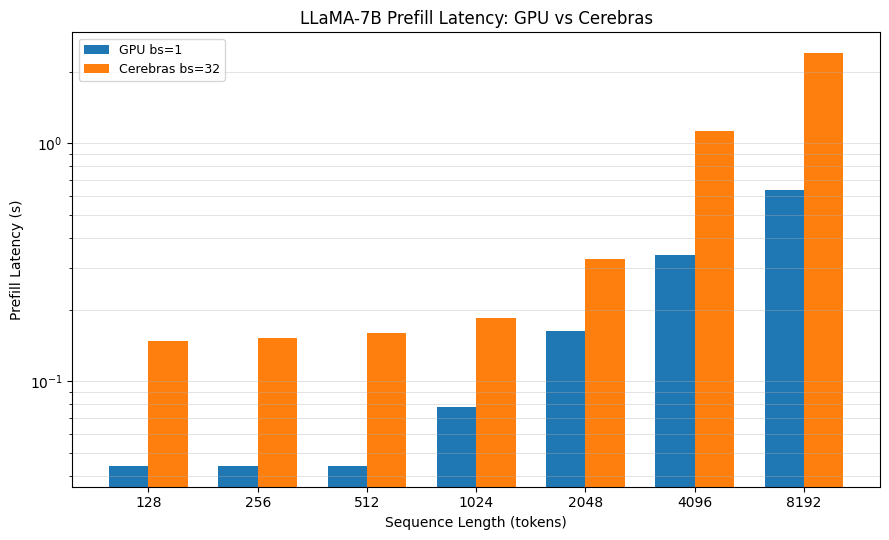

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# X axis
seq = [128, 256, 512, 1024, 2048, 4096, 8192]

# GPU data (seconds)
gpu = {
    1: [0.044, 0.044, 0.044, 0.078, 0.162, 0.340, 0.64]
}
gpu_df = pd.DataFrame(gpu, index=seq)

# Cerebras data (seconds)
cerebras = {
    32: [0.147874306839187, 0.151658767772512, 0.16, 0.184971098265896, 0.32520325203252, 1.13, 2.4]
}
cs_df = pd.DataFrame(cerebras, index=seq)

# Bar positions
x = np.arange(len(seq))
width = 0.36

plt.figure(figsize=(9, 5.5))

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

plt.bar(
    x - width/2,
    gpu_df[1],
    width=width,
    label="GPU bs=1",
    color=colors[0]
)

plt.bar(
    x + width/2,
    cs_df[32],
    width=width,
    label="Cerebras bs=32",
    color=colors[1]
)

plt.xlabel("Sequence Length (tokens)")
plt.ylabel("Prefill Latency (s)")
plt.title("LLaMA-7B Prefill Latency: GPU vs Cerebras")
plt.xticks(x, seq)

# 改成 log y 轴
plt.yscale("log")

plt.grid(True, axis="y", linewidth=0.5, alpha=0.5, which="both")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Optional: save
# plt.savefig("llama7b_prefill_bar_logy.png", dpi=200)

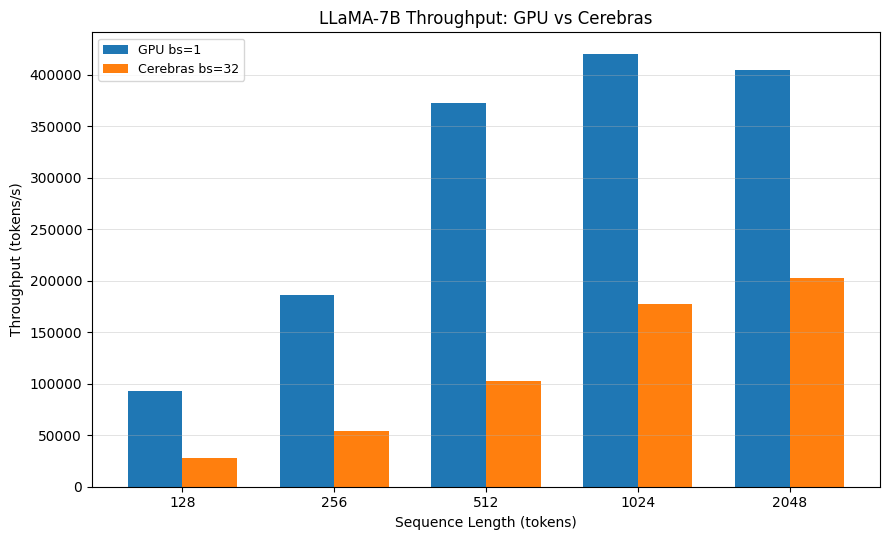

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# X axis
seq = [128, 256, 512, 1024, 2048]

# -----------------------
# GPU 7B throughput (token/s)
# -----------------------
gpu = {
    1: [93090.9090909091, 186181.818181818, 372363.636363636, 420102.564102564, 404543.209876543],
}
gpu_df = pd.DataFrame(gpu, index=seq)

# -----------------------
# Cerebras 7B throughput (token/s)
# -----------------------
cerebras = {
    32: [27699.2, 54016, 102400, 177152, 202141],
}
cs_df = pd.DataFrame(cerebras, index=seq)

# -----------------------
# Grouped bar chart
# -----------------------
x = np.arange(len(seq))
width = 0.36

plt.figure(figsize=(9, 5.5))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

plt.bar(
    x - width/2,
    gpu_df[1],
    width=width,
    color=colors[0],
    label="GPU bs=1"
)

plt.bar(
    x + width/2,
    cs_df[32],
    width=width,
    color=colors[1],
    label="Cerebras bs=32"
)

plt.xlabel("Sequence Length (tokens)")
plt.ylabel("Throughput (tokens/s)")
plt.title("LLaMA-7B Throughput: GPU vs Cerebras")
plt.xticks(x, seq)
plt.grid(True, axis="y", linewidth=0.5, alpha=0.5)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Optional save:
# plt.savefig("llama7b_throughput_bar.png", dpi=200)

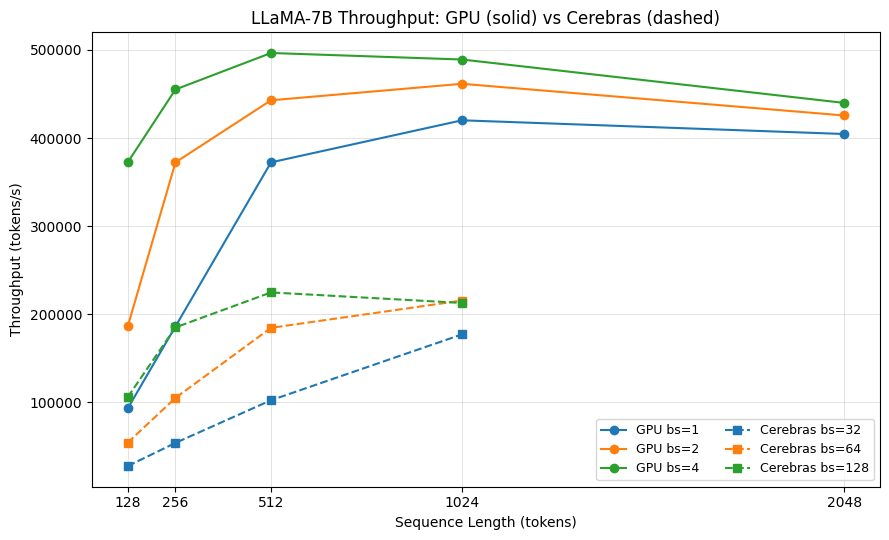

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# X axis
seq = [128, 256, 512, 1024, 2048]

# -----------------------
# GPU 7B throughput (token/s)
# -----------------------
gpu = {
    1: [93090.9090909091, 186181.818181818, 372363.636363636, 420102.564102564, 404543.209876543,370000,350000],
    # 2: [186181.818181818, 372363.636363636, 442810.810810811, 461521.126760563, 425558.441558442],
    # 4: [372363.636363636, 455111.111111111, 496484.848484848, 489074.626865672, 439838.926174497],
}
gpu_df = pd.DataFrame(gpu, index=seq)

# -----------------------
# Cerebras 7B throughput (token/s)
# note: missing seq=2048 -> np.nan
# -----------------------
cerebras = {
    32:  [27699.2, 54016, 102400, 177152,  202141,192321],
    # 64:  [54272,  105088, 184576, 215552,  np.nan],
    # 128: [105984, 185088, 224768, 212787.2, np.nan],
}
cs_df = pd.DataFrame(cerebras, index=seq)

# -----------------------
# Plot (aligned colors by series index)
# -----------------------
plt.figure(figsize=(9, 5.5))

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
gpu_cols = list(gpu_df.columns)  # [1,2,4]
cs_cols  = list(cs_df.columns)   # [32,64,128]

series_colors = [colors[i % len(colors)] for i in range(max(len(gpu_cols), len(cs_cols)))]

# GPU: solid + circle
for i, bs in enumerate(gpu_cols):
    plt.plot(
        gpu_df.index, gpu_df[bs],
        linestyle="-", marker="o",
        color=series_colors[i],
        label=f"GPU bs={bs}",
    )

# Cerebras: dashed + square
for i, bs in enumerate(cs_cols):
    plt.plot(
        cs_df.index, cs_df[bs],
        linestyle="--", marker="s",
        color=series_colors[i],
        label=f"Cerebras bs={bs}",
    )

plt.xlabel("Sequence Length (tokens)")
plt.ylabel("Throughput (tokens/s)")
plt.title("LLaMA-7B Throughput: GPU (solid) vs Cerebras (dashed)")
plt.xticks(seq, seq)
plt.grid(True, linewidth=0.5, alpha=0.5)
plt.legend(ncols=2, fontsize=9)
plt.tight_layout()
plt.show()

# Optional save:
# plt.savefig("llama7b_throughput_gpu_vs_cerebras.png", dpi=200)

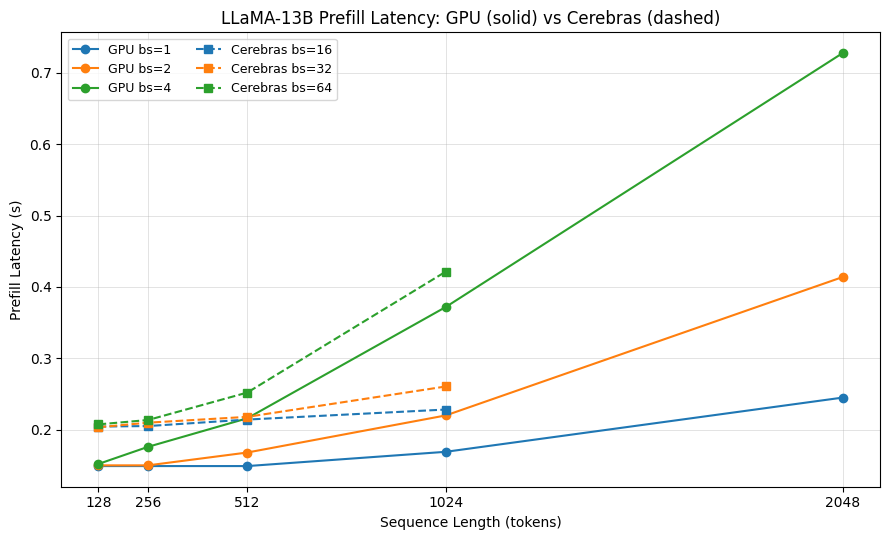

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# X axis
seq = [128, 256, 512, 1024, 2048]

# -----------------------------
# GPU 13B data (seconds)
# -----------------------------
gpu = {
    1: [0.149, 0.149, 0.149, 0.169, 0.245],
    2: [0.150, 0.150, 0.168, 0.220, 0.414],
    4: [0.152, 0.176, 0.216, 0.372, 0.728],
}
gpu_df = pd.DataFrame(gpu, index=seq)


# -----------------------------
# Cerebras 13B data (seconds)
# note: missing seq=2048
# -----------------------------
cerebras = {
    16:  [0.204342273307791, 0.205101910011537, 0.214190093708166, 0.228245363766049, np.nan],
    32:  [0.203432930705658, 0.20983606557377,  0.217983651226158, 0.260565100561843, np.nan],
    64:  [0.207435257511425, 0.213568258417593, 0.252067743205987, 0.421607378129117, np.nan],
}
cs_df = pd.DataFrame(cerebras, index=seq)

plt.figure(figsize=(9, 5.5))

# Align colors by "series index" (1st GPU line matches 1st Cerebras line, etc.)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
series_colors = [colors[i % len(colors)] for i in range(3)]

gpu_cols = list(gpu_df.columns)   # [1, 2, 4]
cs_cols  = list(cs_df.columns)    # [32, 64, 128]

# GPU: solid line, circle marker
for i, bs in enumerate(gpu_cols):
    plt.plot(
        gpu_df.index, gpu_df[bs],
        linestyle="-", marker="o",
        color=series_colors[i],
        label=f"GPU bs={bs}",
    )

# Cerebras: dashed line, square marker (same color as corresponding GPU line)
for i, bs in enumerate(cs_cols):
    plt.plot(
        cs_df.index, cs_df[bs],
        linestyle="--", marker="s",
        color=series_colors[i],
        label=f"Cerebras bs={bs}",
    )

plt.xlabel("Sequence Length (tokens)")
plt.ylabel("Prefill Latency (s)")
plt.title("LLaMA-13B Prefill Latency: GPU (solid) vs Cerebras (dashed)")
plt.xticks(seq, seq)
plt.grid(True, linewidth=0.5, alpha=0.5)
plt.legend(ncols=2, fontsize=9)
plt.tight_layout()
plt.show()

# Optional: save
# plt.savefig("llama7b_prefill_aligned_colors.png", dpi=200)

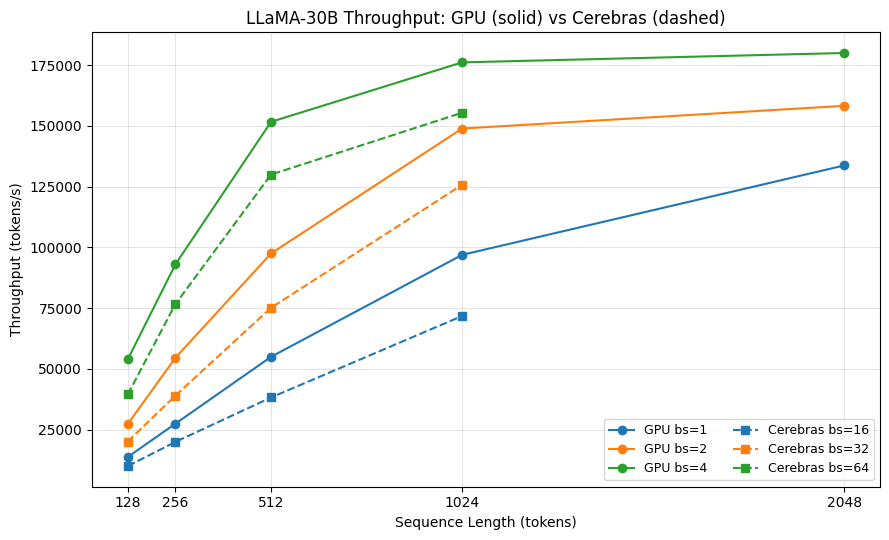

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# X axis
seq = [128, 256, 512, 1024, 2048]

# -----------------------
# GPU 13B throughput (token/s)
# -----------------------
gpu = {
    1: [13744.966442953, 27489.932885906, 54979.8657718121, 96946.7455621302, 133746.93877551],
    2: [27306.6666666667, 54613.3333333333, 97523.8095238095, 148945.454545455, 158299.516908213],
    4: [53894.7368421053, 93090.9090909091, 151703.703703704, 176172.043010753, 180043.956043956],
}
gpu_df = pd.DataFrame(gpu, index=seq)

# -----------------------
# Cerebras 13B throughput (token/s)
# note: missing seq=2048 -> np.nan
# -----------------------
cerebras = {
    16: [10022.4, 19970.56, 38246.4, 71782.4,  np.nan],
    32: [20134.4, 39040.0,  75161.6, 125757.44, np.nan],
    64: [39491.84, 76715.52, 129996.8, 155443.2,  np.nan],
}
cs_df = pd.DataFrame(cerebras, index=seq)

# -----------------------
# Plot (aligned colors by series index)
# -----------------------
plt.figure(figsize=(9, 5.5))

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
gpu_cols = list(gpu_df.columns)  # [1,2,4]
cs_cols  = list(cs_df.columns)   # [16,32,64]

series_colors = [colors[i % len(colors)] for i in range(max(len(gpu_cols), len(cs_cols)))]

# GPU: solid + circle
for i, bs in enumerate(gpu_cols):
    plt.plot(
        gpu_df.index, gpu_df[bs],
        linestyle="-", marker="o",
        color=series_colors[i],
        label=f"GPU bs={bs}",
    )

# Cerebras: dashed + square
for i, bs in enumerate(cs_cols):
    plt.plot(
        cs_df.index, cs_df[bs],
        linestyle="--", marker="s",
        color=series_colors[i],
        label=f"Cerebras bs={bs}",
    )

plt.xlabel("Sequence Length (tokens)")
plt.ylabel("Throughput (tokens/s)")
plt.title("LLaMA-30B Throughput: GPU (solid) vs Cerebras (dashed)")
plt.xticks(seq, seq)
plt.grid(True, linewidth=0.5, alpha=0.5)
plt.legend(ncols=2, fontsize=9)
plt.tight_layout()
plt.show()

# Optional: if you want log-scale on y:
# plt.yscale("log")

# Optional save:
# plt.savefig("llama13b_throughput_gpu_vs_cerebras.png", dpi=200)

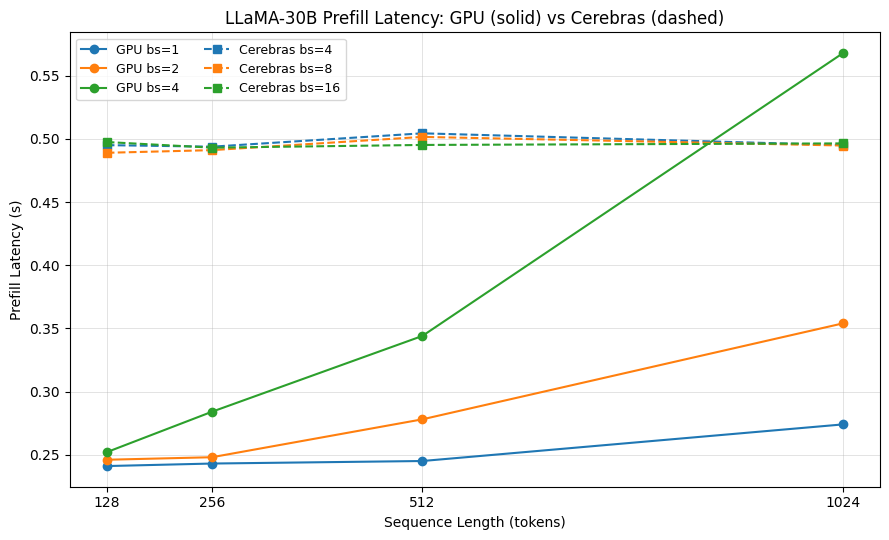

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# X axis
seq = [128, 256, 512, 1024]

# -----------------------
# GPU 30B
# -----------------------
gpu = {
    1: [0.241, 0.243, 0.245, 0.274],
    2: [0.246, 0.248, 0.278, 0.354],
    4: [0.252, 0.284, 0.344, 0.568],
}
gpu_df = pd.DataFrame(gpu, index=seq)

# -----------------------
# Cerebras 30B
# -----------------------
cerebras = {
    4:  [0.495049504950495, 0.493827160493827, 0.504413619167718, 0.495049504950495],
    8:  [0.488997555012225, 0.49109883364027,  0.501567398119122, 0.494743351886209],
    16: [0.497512437810945, 0.49306625577812,  0.49520272361498,  0.496431895749302],
    # 32: [0.488549618320611, 0.501017692187255, 0.495893382922672, 0.617760617760618],
}
cs_df = pd.DataFrame(cerebras, index=seq)

plt.figure(figsize=(9, 5.5))

# Align colors by "series index" (1st GPU line matches 1st Cerebras line, etc.)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
series_colors = [colors[i % len(colors)] for i in range(3)]

gpu_cols = list(gpu_df.columns)   # [1, 2, 4]
cs_cols  = list(cs_df.columns)    # [32, 64, 128]

# GPU: solid line, circle marker
for i, bs in enumerate(gpu_cols):
    plt.plot(
        gpu_df.index, gpu_df[bs],
        linestyle="-", marker="o",
        color=series_colors[i],
        label=f"GPU bs={bs}",
    )

# Cerebras: dashed line, square marker (same color as corresponding GPU line)
for i, bs in enumerate(cs_cols):
    plt.plot(
        cs_df.index, cs_df[bs],
        linestyle="--", marker="s",
        color=series_colors[i],
        label=f"Cerebras bs={bs}",
    )

plt.xlabel("Sequence Length (tokens)")
plt.ylabel("Prefill Latency (s)")
plt.title("LLaMA-30B Prefill Latency: GPU (solid) vs Cerebras (dashed)")
plt.xticks(seq, seq)
plt.grid(True, linewidth=0.5, alpha=0.5)
plt.legend(ncols=2, fontsize=9)
plt.tight_layout()
plt.show()

# Optional: save
# plt.savefig("llama7b_prefill_aligned_colors.png", dpi=200)

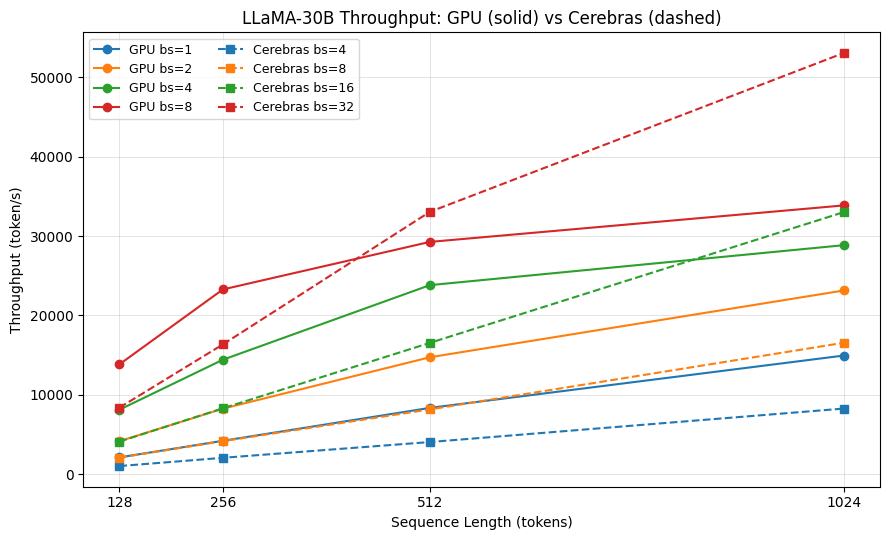

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# X axis
seq = [128, 256, 512, 1024]

gpu = {
    1: [2124.48132780083, 4213.99176954733, 8359.18367346939, 14948.9051094891],
    2: [4162.60162601626, 8258.06451612903, 14733.8129496403, 23141.2429378531],
    4: [8126.98412698413, 14422.5352112676, 23813.9534883721, 28845.0704225352],
    8: [13837.8378378378, 23272.7272727273, 29257.1428571429, 33851.2396694215],
}
gpu_df = pd.DataFrame(gpu, index=seq)

# -----------------------
# Cerebras 70B throughput (token/s)
# note: missing entries -> np.nan; the "0" at seq=1024, bs=8 treated as missing
# -----------------------
cerebras = {
    4:  [1034.24, 2073.6,  4060.16, 8273.92],
    8:  [2094.08, 4170.24, 8166.4,  16558.08],
    16: [4116.48, 8307.2,  16542.72, 33003.52],
    32: [8384.0,  16350.72, 33039.36, 53043.2],
}
cs_df = pd.DataFrame(cerebras, index=seq)

# -----------------------
# Plot (aligned colors by series index)
# -----------------------
plt.figure(figsize=(9, 5.5))

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
gpu_cols = list(gpu_df.columns)  # [1,2,4,8]
cs_cols  = list(cs_df.columns)   # [4,8,16,32]

series_colors = [colors[i % len(colors)] for i in range(max(len(gpu_cols), len(cs_cols)))]

# GPU: solid + circle
for i, bs in enumerate(gpu_cols):
    plt.plot(
        gpu_df.index, gpu_df[bs],
        linestyle="-", marker="o",
        color=series_colors[i],
        label=f"GPU bs={bs}",
    )

# Cerebras: dashed + square
for i, bs in enumerate(cs_cols):
    plt.plot(
        cs_df.index, cs_df[bs],
        linestyle="--", marker="s",
        color=series_colors[i],
        label=f"Cerebras bs={bs}",
    )

plt.xlabel("Sequence Length (tokens)")
plt.ylabel("Throughput (token/s)")
plt.title("LLaMA-30B Throughput: GPU (solid) vs Cerebras (dashed)")
plt.xticks(seq, seq)
plt.grid(True, linewidth=0.5, alpha=0.5)
plt.legend(ncols=2, fontsize=9)
plt.tight_layout()
plt.show()

# Optional: log-scale y-axis
# plt.yscale("log")

# Optional save:
# plt.savefig("llama70b_throughput_gpu_vs_cerebras.png", dpi=200)

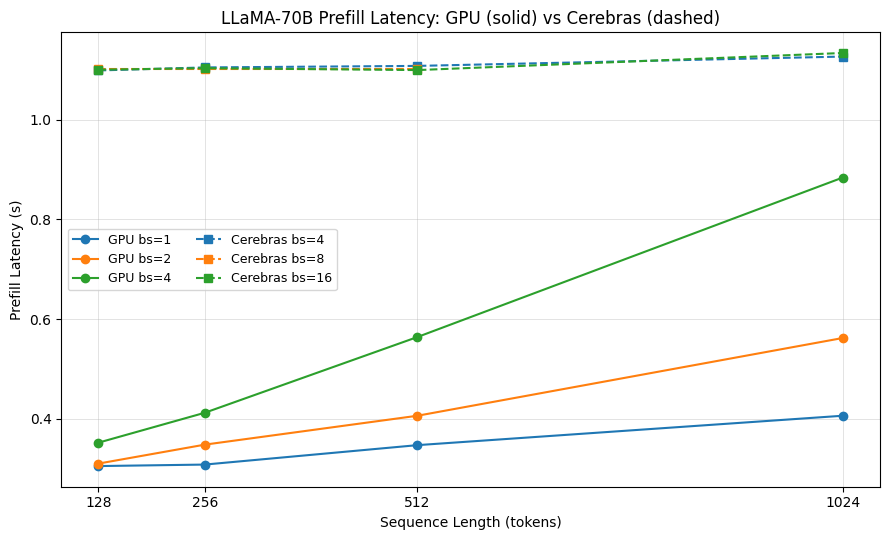

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# X axis
seq = [128, 256, 512, 1024]

# -----------------------
# GPU 70B (seconds)
# -----------------------
gpu = {
    1: [0.305, 0.308, 0.347, 0.406,0.562,0.884],
    2: [0.310, 0.348, 0.406, 0.562],
    4: [0.352, 0.412, 0.564, 0.884],
    #8: [0.424, 0.576, 0.864, 1.624],
}
gpu_df = pd.DataFrame(gpu, index=seq)

# -----------------------
# Cerebras 70B (seconds)
# missing entries -> np.nan
# -----------------------
cerebras = {
    4:  [1.0989010989011,  1.10497237569061, 1.10803324099723, 1.12676056338028,1.11,1.13],
    8:  [1.10192837465565, 1.10192837465565, 1.10192837465565, np.nan],
    16: [1.10041265474553, 1.10344827586207, 1.09965635738832, 1.13394755492558],
    #32: [1.10306790761806, 1.10116999311769, np.nan, np.nan],
}
cs_df = pd.DataFrame(cerebras, index=seq)

plt.figure(figsize=(9, 5.5))

# Align colors by "series index" (1st GPU line matches 1st Cerebras line, etc.)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
series_colors = [colors[i % len(colors)] for i in range(3)]

gpu_cols = list(gpu_df.columns)   # [1, 2, 4]
cs_cols  = list(cs_df.columns)    # [32, 64, 128]

# GPU: solid line, circle marker
for i, bs in enumerate(gpu_cols):
    plt.plot(
        gpu_df.index, gpu_df[bs],
        linestyle="-", marker="o",
        color=series_colors[i],
        label=f"GPU bs={bs}",
    )

# Cerebras: dashed line, square marker (same color as corresponding GPU line)
for i, bs in enumerate(cs_cols):
    plt.plot(
        cs_df.index, cs_df[bs],
        linestyle="--", marker="s",
        color=series_colors[i],
        label=f"Cerebras bs={bs}",
    )

plt.xlabel("Sequence Length (tokens)")
plt.ylabel("Prefill Latency (s)")
plt.title("LLaMA-70B Prefill Latency: GPU (solid) vs Cerebras (dashed)")
plt.xticks(seq, seq)
plt.grid(True, linewidth=0.5, alpha=0.5)
plt.legend(ncols=2, fontsize=9)
plt.tight_layout()
plt.show()

# Optional: save
# plt.savefig("llama7b_prefill_aligned_colors.png", dpi=200)

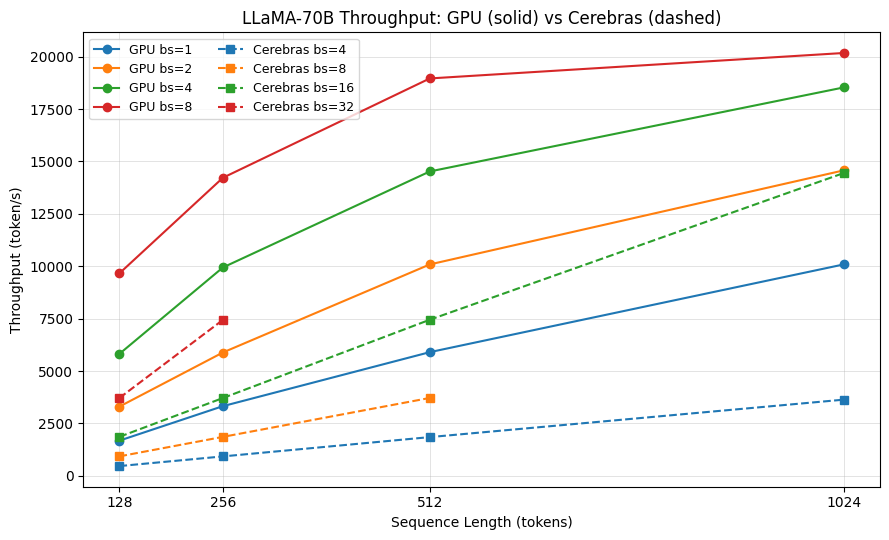

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# X axis
seq = [128, 256, 512, 1024]

# -----------------------
# GPU 70B throughput (token/s)
# -----------------------
gpu = {
    1: [1678.68852459016, 3324.67532467532, 5902.01729106628, 10088.6699507389, 14550,18700,20100],
    2: [3303.22580645161, 5885.05747126437, 10088.6699507389, 14576.512455516],
    4: [5818.18181818182, 9941.74757281553, 14524.8226950355, 18533.9366515837],
    8: [9660.37735849057, 14222.2222222222, 18962.962962963, 20177.3399014778],
}
gpu_df = pd.DataFrame(gpu, index=seq)

# -----------------------
# Cerebras 70B throughput (token/s)
# note: missing entries -> np.nan; the "0" at seq=1024, bs=8 treated as missing
# -----------------------
cerebras = {
    4:  [465.92, 926.72, 1848.32, 3635.2,7450,14448],
    # 8:  [929.28, 1858.56, 3717.12, np.nan],   # was 0
    # 16: [1861.12, 3712.0, 7449.6,  14448.64],
    # 32: [3713.28, 7439.36, np.nan, np.nan],
}
cs_df = pd.DataFrame(cerebras, index=seq)

# -----------------------
# Plot (aligned colors by series index)
# -----------------------
plt.figure(figsize=(9, 5.5))

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
gpu_cols = list(gpu_df.columns)  # [1,2,4,8]
cs_cols  = list(cs_df.columns)   # [4,8,16,32]

series_colors = [colors[i % len(colors)] for i in range(max(len(gpu_cols), len(cs_cols)))]

# GPU: solid + circle
for i, bs in enumerate(gpu_cols):
    plt.plot(
        gpu_df.index, gpu_df[bs],
        linestyle="-", marker="o",
        color=series_colors[i],
        label=f"GPU bs={bs}",
    )

# Cerebras: dashed + square
for i, bs in enumerate(cs_cols):
    plt.plot(
        cs_df.index, cs_df[bs],
        linestyle="--", marker="s",
        color=series_colors[i],
        label=f"Cerebras bs={bs}",
    )

plt.xlabel("Sequence Length (tokens)")
plt.ylabel("Throughput (token/s)")
plt.title("LLaMA-70B Throughput: GPU (solid) vs Cerebras (dashed)")
plt.xticks(seq, seq)
plt.grid(True, linewidth=0.5, alpha=0.5)
plt.legend(ncols=2, fontsize=9)
plt.tight_layout()
plt.show()

# Optional: log-scale y-axis
# plt.yscale("log")

# Optional save:
# plt.savefig("llama70b_throughput_gpu_vs_cerebras.png", dpi=200)

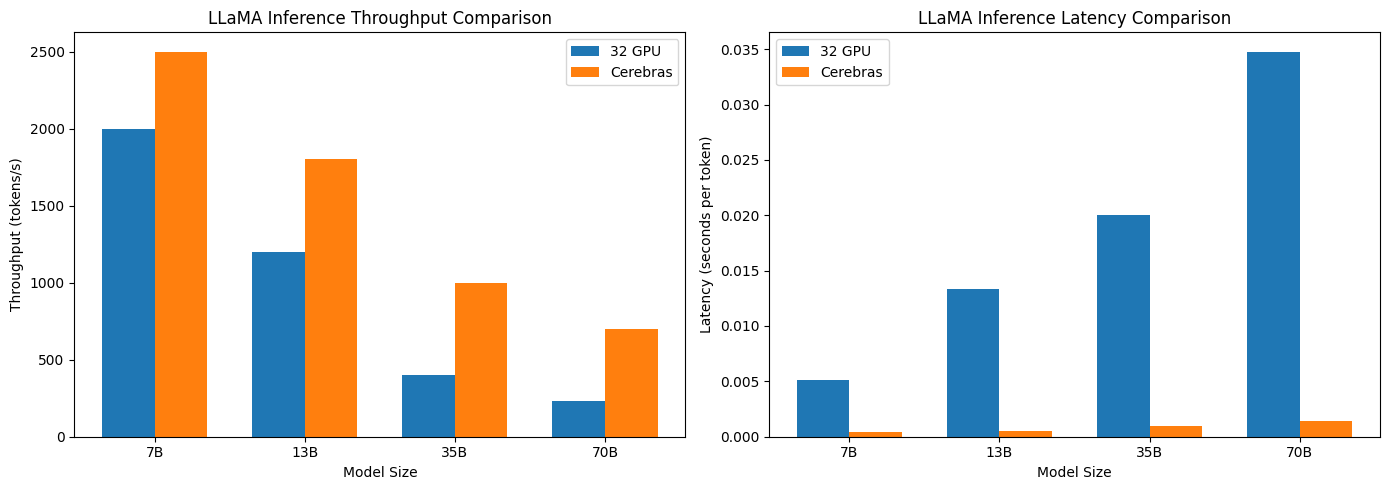

In [141]:
import matplotlib.pyplot as plt

# Data
models = ["7B", "13B", "35B", "70B"]

gpu32 = [2000, 1200, 400, 230]
cerebras = [2500, 1800, 1000, 700]

gpu_latency = [0.00516129032258065, 0.0133333333333333, 0.02, 0.0347826086956522]
cerebras_latency = [0.0004, 0.000555555555555556, 0.001, 0.00142857142857143]

x = range(len(models))
width = 0.35

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------
# Throughput subplot
# -------------------------
axes[0].bar([i - width/2 for i in x], gpu32, width, label="32 GPU")
axes[0].bar([i + width/2 for i in x], cerebras, width, label="Cerebras")

axes[0].set_xlabel("Model Size")
axes[0].set_ylabel("Throughput (tokens/s)")
axes[0].set_title("LLaMA Inference Throughput Comparison")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(models)
axes[0].legend()

# -------------------------
# Latency subplot
# -------------------------
axes[1].bar([i - width/2 for i in x], gpu_latency, width, label="32 GPU")
axes[1].bar([i + width/2 for i in x], cerebras_latency, width, label="Cerebras")

axes[1].set_xlabel("Model Size")
axes[1].set_ylabel("Latency (seconds per token)")
axes[1].set_title("LLaMA Inference Latency Comparison")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(models)
axes[1].legend()

plt.tight_layout()
plt.show()

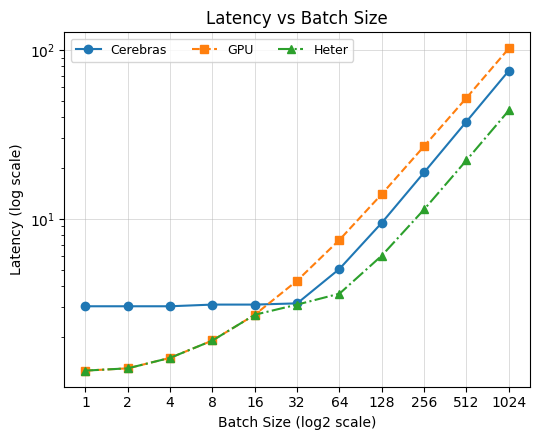

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Batch sizes
x = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024], dtype=float)

# Latency data
cerebras = np.array([
    3.03030303030303, 3.03030303030303, 3.03030303030303, 3.10077519379845,
    3.10077519379845, 3.15270935960591, 5.04731861198738, 9.46745562130178,
    18.8235294117647, 37.6470588235294, 75.2941176470588
], dtype=float)

gpu = np.array([
    1.26, 1.3, 1.5, 1.9,
    2.7, 4.3, 7.5, 14,
    26.9, 52, 102
], dtype=float)

heter = np.array([
    1.26, 1.3, 1.5, 1.9, 2.7,
    3.1, 3.6, 6.05, 11.36,
    22.2, 43.8
], dtype=float)

# Plot (6:4 aspect ratio)
plt.figure(figsize=(5.5, 4.5))
plt.plot(x, cerebras, linestyle='-',  marker='o', label='Cerebras')
plt.plot(x, gpu,      linestyle='--', marker='s', label='GPU')
plt.plot(x, heter,    linestyle='-.', marker='^', label='Heter')

plt.xscale('log', base=2)   # log2 x-axis for batch size
plt.yscale('log')           # log y-axis for latency
plt.xticks(x, [str(int(v)) for v in x])

plt.xlabel('Batch Size (log2 scale)')
plt.ylabel('Latency (log scale)')
plt.title('Latency vs Batch Size')
plt.grid(True, linewidth=0.5, alpha=0.6)
plt.legend(ncol=3, fontsize=9, loc='upper left')
plt.tight_layout()

# Save (optional)
#plt.savefig('latency_line_logy_6x4.png', dpi=300, bbox_inches='tight')

plt.show()


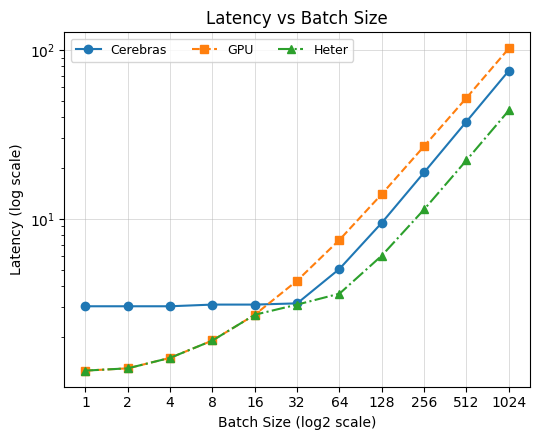

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Batch sizes
x = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024], dtype=float)

# Latency data
cerebras = np.array([
    3.03030303030303, 3.03030303030303, 3.03030303030303, 3.10077519379845,
    3.10077519379845, 3.15270935960591, 5.04731861198738, 9.46745562130178,
    18.8235294117647, 37.6470588235294, 75.2941176470588
], dtype=float)

gpu = np.array([
    1.26, 1.3, 1.5, 1.9,
    2.7, 4.3, 7.5, 14,
    26.9, 52, 102
], dtype=float)

heter = np.array([
    1.26, 1.3, 1.5, 1.9, 2.7,
    3.1, 3.6, 6.05, 11.36,
    22.2, 43.8
], dtype=float)

# Plot (6:4 aspect ratio)
plt.figure(figsize=(5.5, 4.5))
plt.plot(x, cerebras, linestyle='-',  marker='o', label='Cerebras')
plt.plot(x, gpu,      linestyle='--', marker='s', label='GPU')
plt.plot(x, heter,    linestyle='-.', marker='^', label='Heter')

plt.xscale('log', base=2)   # log2 x-axis for batch size
plt.yscale('log')           # log y-axis for latency
plt.xticks(x, [str(int(v)) for v in x])

plt.xlabel('Batch Size (log2 scale)')
plt.ylabel('Latency (log scale)')
plt.title('Latency vs Batch Size')
plt.grid(True, linewidth=0.5, alpha=0.6)
plt.legend(ncol=3, fontsize=9, loc='upper left')
plt.tight_layout()

# Save (optional)
#plt.savefig('latency_line_logy_6x4.png', dpi=300, bbox_inches='tight')

plt.show()


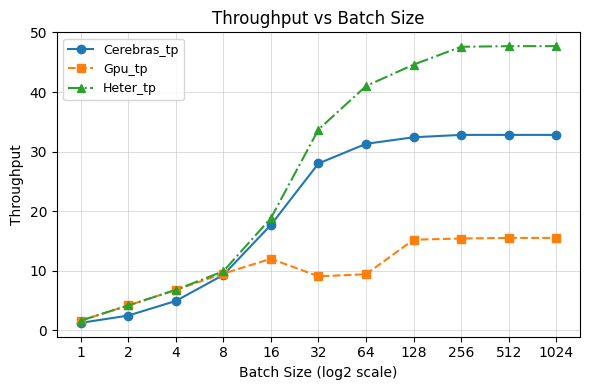

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Batch sizes
x = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024], dtype=float)

# Latency data
cerebras = np.array([1.23, 2.46, 4.91, 9.28, 17.68, 28.0, 31.3, 32.4, 32.8, 32.8, 32.8], dtype=float)
gpu      = np.array([1.61, 4.16, 6.77, 9.5, 12.0, 9.05, 9.4, 15.2, 15.4, 15.5, 15.5], dtype=float)
heter    = np.array([1.61, 4.16, 6.77, 9.9, 18.82, 33.7, 41.0, 44.6, 47.6, 47.7, 47.7], dtype=float)

# Plot (6:4 aspect ratio)
plt.figure(figsize=(6, 4))
plt.plot(x, cerebras, linestyle='-',  marker='o', label='Cerebras_tp')
plt.plot(x, gpu,      linestyle='--', marker='s', label='Gpu_tp')
plt.plot(x, heter,    linestyle='-.', marker='^', label='Heter_tp')

# X as log2 because batch sizes double
plt.xscale('log', base=2)
plt.xticks(x, [str(int(v)) for v in x])

plt.xlabel('Batch Size (log2 scale)')
plt.ylabel('Throughput')
plt.title('Throughput vs Batch Size')
plt.grid(True, linewidth=0.5, alpha=0.6)
plt.legend(ncol=1, fontsize=9, loc='upper left')
plt.tight_layout()

# Save (optional)

plt.show()


In [13]:
from dataclasses import dataclass
from typing import List, Optional, Tuple

@dataclass
class Plan:
    layers_on_cerebras: int
    layers_on_gpus: List[int]          # length = num_gpus
    stage_times_ms: List[float]        # per GPU stage time
    cerebras_time_ms: float
    bottleneck_ms: float

def best_pp_partition(
    total_layers: int = 32,
    num_gpus: int = 16,
    gpu_layer_time_ms: float = 400.0,
    cerebras_layer_time_ms: float = 25.0,
    must_use_cerebras: bool = False,
    min_cerebras_layers: int = 0,
) -> Plan:
    """
    Find a partition of total_layers across num_gpus GPUs and 1 Cerebras
    that minimizes the pipeline bottleneck (max stage time).
    Assumes each stage time is linear in number of layers assigned:
      GPU_i time = layers_i * gpu_layer_time_ms
      Cerebras time = x * cerebras_layer_time_ms

    Returns a simple distribution: as balanced as possible under the chosen x.
    """
    if must_use_cerebras:
        min_x = max(1, min_cerebras_layers)
    else:
        min_x = max(0, min_cerebras_layers)

    best: Optional[Plan] = None

    # enumerate how many layers go to Cerebras
    for x in range(min_x, total_layers + 1):
        remaining = total_layers - x

        # Distribute remaining layers across GPUs as evenly as possible:
        # e.g., remaining=31 over 16 => 15 GPUs get 2, 1 GPU gets 1.
        base = remaining // num_gpus
        r = remaining % num_gpus
        layers_on_gpus = [base + 1] * r + [base] * (num_gpus - r)

        stage_times = [l * gpu_layer_time_ms for l in layers_on_gpus]
        c_time = x * cerebras_layer_time_ms
        bottleneck = max(max(stage_times) if stage_times else 0.0, c_time)

        plan = Plan(
            layers_on_cerebras=x,
            layers_on_gpus=layers_on_gpus,
            stage_times_ms=stage_times,
            cerebras_time_ms=c_time,
            bottleneck_ms=bottleneck,
        )

        if best is None or plan.bottleneck_ms < best.bottleneck_ms:
            best = plan

    assert best is not None
    return best

def pretty_print(plan: Plan) -> None:
    print(f"Layers on Cerebras: {plan.layers_on_cerebras}  "
          f"(time={plan.cerebras_time_ms:.1f} ms)")
    print(f"GPU layer counts (len={len(plan.layers_on_gpus)}): {plan.layers_on_gpus}")
    print(f"GPU stage times (ms): {[round(t, 1) for t in plan.stage_times_ms]}")
    print(f"Bottleneck (max stage time): {plan.bottleneck_ms:.1f} ms")

if __name__ == "__main__":
    # Case 1: Cerebras optional (best throughput)
    plan1 = best_pp_partition(must_use_cerebras=False)
    print("=== Cerebras optional ===")
    pretty_print(plan1)

    # Case 2: Cerebras must be used (at least 1 layer)
    plan2 = best_pp_partition(must_use_cerebras=True)
    print("\n=== Cerebras must be used (>=1 layer) ===")
    pretty_print(plan2)

=== Cerebras optional ===
Layers on Cerebras: 16  (time=400.0 ms)
GPU layer counts (len=16): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
GPU stage times (ms): [400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0]
Bottleneck (max stage time): 400.0 ms

=== Cerebras must be used (>=1 layer) ===
Layers on Cerebras: 16  (time=400.0 ms)
GPU layer counts (len=16): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
GPU stage times (ms): [400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0, 400.0]
Bottleneck (max stage time): 400.0 ms


In [63]:
def required_bandwidth_gBs(size_gb, time_s):
    """
    计算所需带宽（GB/s）

    参数:
        size_gb (float): 数据大小，单位 GB
        time_s (float): 允许传输时间，单位 秒

    返回:
        float: 所需带宽，单位 GB/s
    """
    if time_s <= 0:
        raise ValueError("time_s must be > 0")

    return size_gb / time_s


# 例子：13.5 GB，希望在 0.05 秒内传完，需要多少 GB/s
size_gb = 140
time_s = 12.45

bandwidth_gBs = required_bandwidth_gBs(size_gb, time_s)
print(f"Required bandwidth: {bandwidth_gBs:.6f} GB/s")
print(f"Required bandwidth: {bandwidth_gBs*8:.3f} Gbps")

Required bandwidth: 11.244980 GB/s
Required bandwidth: 89.960 Gbps


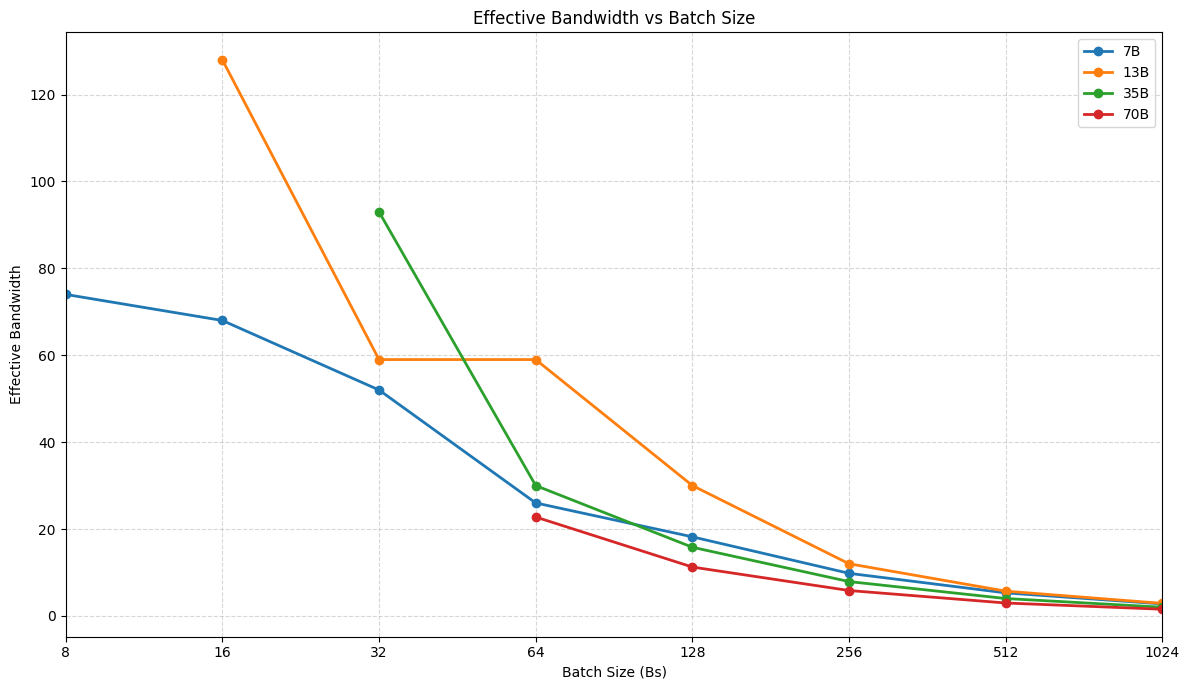

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# x轴：batch size
x = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024], dtype=float)

# y轴：latency
y_7b  = np.array([0, 0, 0, 74, 68, 52, 26, 18.2, 9.8, 5.3, 2.76], dtype=float)
y_13b = np.array([0, 0, 0, 0, 128, 59, 59, 30, 12, 5.7, 2.88], dtype=float)
y_35b = np.array([0, 0, 0, 0, 0, 93, 30, 15.8, 7.9, 4, 2], dtype=float)
y_70b = np.array([0, 0, 0, 0, 0, 0, 22.7642276422764, 11.2449799196787,
                  5.8455114822547, 2.96924708377519, 1.53256704980843], dtype=float)

# 把0替换成NaN，这样图里不会显示0点，也不会连到0
y_7b[y_7b == 0] = np.nan
y_13b[y_13b == 0] = np.nan
y_35b[y_35b == 0] = np.nan
y_70b[y_70b == 0] = np.nan

plt.figure(figsize=(12, 7))

plt.plot(x, y_7b,  marker='o', linewidth=2, label='7B')
plt.plot(x, y_13b, marker='o', linewidth=2, label='13B')
plt.plot(x, y_35b, marker='o', linewidth=2, label='35B')
plt.plot(x, y_70b, marker='o', linewidth=2, label='70B')

plt.xscale('log', base=2)
plt.xlim(8, 1024)  # 横坐标从8开始
plt.xticks([8, 16, 32, 64, 128, 256, 512, 1024],
           ['8', '16', '32', '64', '128', '256', '512', '1024'])

plt.xlabel('Batch Size (Bs)')
plt.ylabel('Effective Bandwidth')
plt.title('Effective Bandwidth vs Batch Size')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("/Users/huziyu/Downloads/dp_bandwidth.pdf", bbox_inches="tight")
plt.show()

In [82]:
import math
from typing import List, Dict, Tuple

# =========================================================
# 1. 你给的数据：不同 microbatch size 下的单层 latency
#    单位你自己定（比如 ms）
# =========================================================
LATENCY_1LAYER = {
    "cerebras": {
        1: 47.3484848484848,
        2: 47.3484848484848,
        4: 47.3484848484848,
        8: 48.4496124031008,
        16: 48.4496124031008,
        32: 49.2610837438423,
        64: 78.8643533123028,
    },
    "gpu": {
        1: 61.0,
        2: 69.0,
        4: 92.0,
        8: 144.0,
        16: 249.0,
        32: 461.0,
        # 64 没有数据，先不填
    }
}


# =========================================================
# 2. 工具函数
# =========================================================
def get_1layer_latency(device: str, microbatch: int) -> float:
    """
    根据设备类型和 microbatch size 获取单层 latency。
    device: 'gpu' or 'cerebras'
    """
    device = device.lower()
    if device not in LATENCY_1LAYER:
        raise ValueError(f"Unknown device: {device}")

    table = LATENCY_1LAYER[device]
    if microbatch not in table:
        raise ValueError(
            f"No latency data for device={device}, microbatch={microbatch}. "
            f"Available: {sorted(table.keys())}"
        )
    return table[microbatch]


def balanced_split(total: int, parts: int) -> List[int]:
    """
    把 total 尽量平均地分成 parts 份，返回每份的整数大小。
    例如 balanced_split(10, 3) -> [4, 3, 3]
    """
    base = total // parts
    rem = total % parts
    return [base + 1 if i < rem else base for i in range(parts)]


def make_ranges(counts: List[int], start_layer: int = 1) -> List[Tuple[int, int]]:
    """
    根据每个 stage 的层数，生成 layer 范围。
    例如 [6,6,7] -> [(1,6),(7,12),(13,19)]
    """
    ranges = []
    cur = start_layer
    for c in counts:
        if c == 0:
            ranges.append((cur, cur - 1))
        else:
            ranges.append((cur, cur + c - 1))
            cur += c
    return ranges


# =========================================================
# 3. 核心优化：
#    枚举“总共分给 GPU 多少层”，剩下给 Cerebras
#    然后在各自 device 内部尽量平均分给每个 stage
#    目标：最小化最大 stage latency（pipeline bottleneck）
# =========================================================
def find_best_pipeline_partition(
    total_layers: int,
    gpu_stages: int,
    gpu_microbatch: int,
    cerebras_stages: int,
    cerebras_microbatch: int,
    must_use_all_stages: bool = True,
) -> Dict:
    """
    返回最合理的 pipeline layer 放置方法。

    参数:
        total_layers: 总 layer 数，例如 64
        gpu_stages: GPU stage 数
        gpu_microbatch: GPU 使用的 microbatch size
        cerebras_stages: Cerebras stage 数
        cerebras_microbatch: Cerebras 使用的 microbatch size
        must_use_all_stages:
            True  -> 每个 stage 至少放 1 层（如果总层数允许）
            False -> 允许某些 stage 放 0 层

    返回:
        一个 dict，包含最优分配细节
    """
    if gpu_stages < 0 or cerebras_stages < 0:
        raise ValueError("Stage counts must be non-negative.")
    if gpu_stages + cerebras_stages == 0:
        raise ValueError("At least one stage is required.")

    gpu_t1 = get_1layer_latency("gpu", gpu_microbatch) if gpu_stages > 0 else None
    cer_t1 = get_1layer_latency("cerebras", cerebras_microbatch) if cerebras_stages > 0 else None

    best = None

    # 枚举分给 GPU 的总层数
    for gpu_total_layers in range(total_layers + 1):
        cer_total_layers = total_layers - gpu_total_layers

        # 是否要求每个 stage 至少 1 层
        if must_use_all_stages:
            if gpu_stages > 0 and gpu_total_layers < gpu_stages:
                continue
            if cerebras_stages > 0 and cer_total_layers < cerebras_stages:
                continue

        # 构造各自内部的均匀分配
        gpu_counts = balanced_split(gpu_total_layers, gpu_stages) if gpu_stages > 0 else []
        cer_counts = balanced_split(cer_total_layers, cerebras_stages) if cerebras_stages > 0 else []

        # 若不允许 0 层但出现了 0 层，跳过
        if must_use_all_stages:
            if any(x <= 0 for x in gpu_counts + cer_counts):
                continue

        # 每个 stage 的时间
        gpu_stage_times = [c * gpu_t1 for c in gpu_counts] if gpu_stages > 0 else []
        cer_stage_times = [c * cer_t1 for c in cer_counts] if cerebras_stages > 0 else []

        all_times = gpu_stage_times + cer_stage_times
        bottleneck = max(all_times)

        # 次级目标：让 stage 时间更均衡
        spread = max(all_times) - min(all_times)
        # 再次级目标：减少整数分配带来的不均匀
        layer_spread = (max(gpu_counts + cer_counts) - min(gpu_counts + cer_counts)) if (gpu_counts + cer_counts) else 0

        candidate = {
            "gpu_total_layers": gpu_total_layers,
            "cerebras_total_layers": cer_total_layers,
            "gpu_counts": gpu_counts,
            "cerebras_counts": cer_counts,
            "gpu_stage_times": gpu_stage_times,
            "cerebras_stage_times": cer_stage_times,
            "bottleneck_time": bottleneck,
            "time_spread": spread,
            "layer_spread": layer_spread,
            "gpu_1layer_latency": gpu_t1,
            "cerebras_1layer_latency": cer_t1,
        }

        if best is None:
            best = candidate
        else:
            # 按优先级比较
            if candidate["bottleneck_time"] < best["bottleneck_time"]:
                best = candidate
            elif math.isclose(candidate["bottleneck_time"], best["bottleneck_time"], rel_tol=1e-12, abs_tol=1e-12):
                if candidate["time_spread"] < best["time_spread"]:
                    best = candidate
                elif math.isclose(candidate["time_spread"], best["time_spread"], rel_tol=1e-12, abs_tol=1e-12):
                    if candidate["layer_spread"] < best["layer_spread"]:
                        best = candidate

    if best is None:
        raise ValueError(
            "No feasible solution found. "
            "Check whether total_layers is enough for all stages."
        )

    # 构造顺序：默认 GPU 在前，Cerebras 在后
    gpu_ranges = make_ranges(best["gpu_counts"], start_layer=1)
    start_cer = best["gpu_total_layers"] + 1
    cer_ranges = make_ranges(best["cerebras_counts"], start_layer=start_cer)

    # 汇总成表格结构
    stage_plan = []

    for i, (cnt, t, rg) in enumerate(zip(best["gpu_counts"], best["gpu_stage_times"], gpu_ranges), start=1):
        stage_plan.append({
            "stage_name": f"GPU-{i}",
            "device": "GPU",
            "layers": cnt,
            "layer_range": rg,
            "microbatch": gpu_microbatch,
            "time": t,
        })

    for i, (cnt, t, rg) in enumerate(zip(best["cerebras_counts"], best["cerebras_stage_times"], cer_ranges), start=1):
        stage_plan.append({
            "stage_name": f"Cerebras-{i}",
            "device": "Cerebras",
            "layers": cnt,
            "layer_range": rg,
            "microbatch": cerebras_microbatch,
            "time": t,
        })

    best["stage_plan"] = stage_plan
    return best


# =========================================================
# 4. 打印结果
# =========================================================
def print_plan(result: Dict):
    print("=" * 80)
    print("Best pipeline partition")
    print("=" * 80)
    print(f"GPU total layers       : {result['gpu_total_layers']}")
    print(f"Cerebras total layers  : {result['cerebras_total_layers']}")
    print(f"GPU 1-layer latency    : {result['gpu_1layer_latency']}")
    print(f"Cerebras 1-layer latency: {result['cerebras_1layer_latency']}")
    print(f"Pipeline bottleneck    : {result['bottleneck_time']:.4f}")
    print(f"Stage time spread      : {result['time_spread']:.4f}")
    print()

    print(f"{'Stage':<15} {'Device':<12} {'Layers':<8} {'LayerRange':<18} {'MB':<6} {'StageTime':<12}")
    print("-" * 80)
    for row in result["stage_plan"]:
        print(
            f"{row['stage_name']:<15} "
            f"{row['device']:<12} "
            f"{row['layers']:<8} "
            f"{str(row['layer_range']):<18} "
            f"{row['microbatch']:<6} "
            f"{row['time']:<12.4f}"
        )
    print("-" * 80)


# =========================================================
# 5. 例子
# =========================================================
# 例1：你前面提到的类似场景
# 64 layers, 8 GPU stages, 2 Cerebras stages
# 假设 GPU microbatch=4, Cerebras microbatch=8
result = find_best_pipeline_partition(
    total_layers=64,
    gpu_stages=8,
    gpu_microbatch=4,
    cerebras_stages=2,
    cerebras_microbatch=8,
    must_use_all_stages=True,
)
print_plan(result)

Best pipeline partition
GPU total layers       : 44
Cerebras total layers  : 20
GPU 1-layer latency    : 92.0
Cerebras 1-layer latency: 48.4496124031008
Pipeline bottleneck    : 552.0000
Stage time spread      : 92.0000

Stage           Device       Layers   LayerRange         MB     StageTime   
--------------------------------------------------------------------------------
GPU-1           GPU          6        (1, 6)             4      552.0000    
GPU-2           GPU          6        (7, 12)            4      552.0000    
GPU-3           GPU          6        (13, 18)           4      552.0000    
GPU-4           GPU          6        (19, 24)           4      552.0000    
GPU-5           GPU          5        (25, 29)           4      460.0000    
GPU-6           GPU          5        (30, 34)           4      460.0000    
GPU-7           GPU          5        (35, 39)           4      460.0000    
GPU-8           GPU          5        (40, 44)           4      460.0000    
Cereb

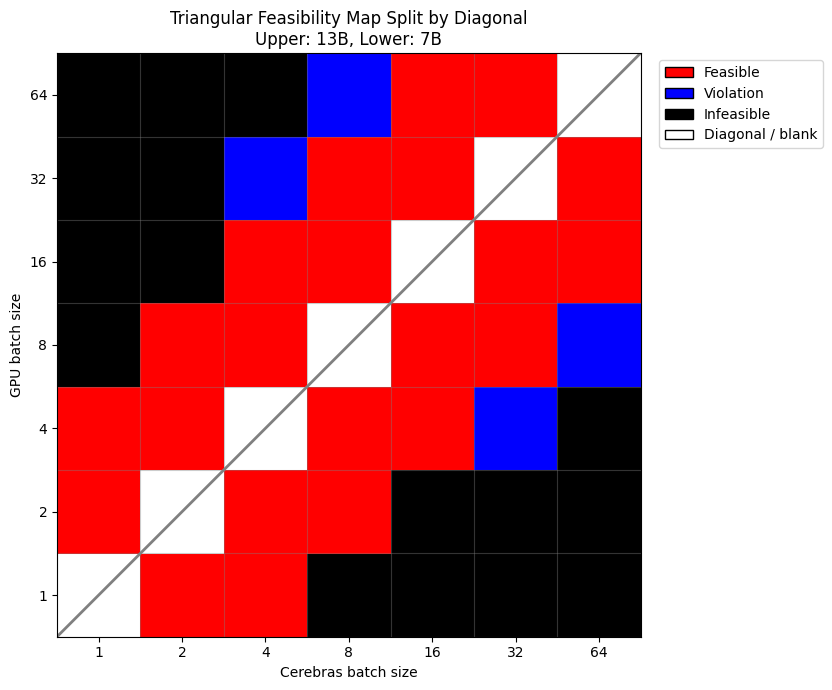

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

gpu_bs = [1, 2, 4, 8, 16, 32, 64]
cer_bs = [1, 2, 4, 8, 16, 32, 64]
n = len(gpu_bs)

# -1 = diagonal / blank
#  0 = black (infeasible)
#  1 = blue  (violation)
#  2 = red   (feasible)
combined = np.full((n, n), -1, dtype=int)

# Lower triangle: 7B
lower_7b = {
    (1, 0): 2,
    (2, 0): 2, (2, 1): 2,
    (3, 0): 0, (3, 1): 2, (3, 2): 2,
    (4, 0): 0, (4, 1): 0, (4, 2): 2, (4, 3): 2,
    (5, 0): 0, (5, 1): 0, (5, 2): 1, (5, 3): 2, (5, 4): 2,
    (6, 0): 0, (6, 1): 0, (6, 2): 0, (6, 3): 1, (6, 4): 2, (6, 5): 2,
}

# Upper triangle: 13B
upper_13b = {
    (0, 1): 2,
    (0, 2): 2, (1, 2): 2,
    (0, 3): 0, (1, 3): 2, (2, 3): 2,
    (0, 4): 0, (1, 4): 0, (2, 4): 2, (3, 4): 2,
    (0, 5): 0, (1, 5): 0, (2, 5): 1, (3, 5): 2, (4, 5): 2,
    (0, 6): 0, (1, 6): 0, (2, 6): 0, (3, 6): 1, (4, 6): 2, (5, 6): 2,
}

for (i, j), v in lower_7b.items():
    combined[i, j] = v

for (i, j), v in upper_13b.items():
    combined[i, j] = v

display_grid = combined + 1
cmap = ListedColormap(["white", "black", "blue", "red"])

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(display_grid, cmap=cmap, interpolation="nearest", origin="lower")

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(cer_bs)
ax.set_yticklabels(gpu_bs)
ax.set_xlabel("Cerebras batch size")
ax.set_ylabel("GPU batch size")
ax.set_title("Triangular Feasibility Map Split by Diagonal\nUpper: 13B, Lower: 7B")

ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.8, alpha=0.4)
ax.tick_params(which="minor", bottom=False, left=False)

ax.plot([-0.5, n - 0.5], [-0.5, n - 0.5], color="gray", linewidth=2)

ax.text(4.8, 1.0, "13B", fontsize=16, weight="bold", color="black")
ax.text(1.0, 4.8, "7B", fontsize=16, weight="bold", color="black")

legend_elements = [
    Patch(facecolor="red", edgecolor="black", label="Feasible"),
    Patch(facecolor="blue", edgecolor="black", label="Violation"),
    Patch(facecolor="black", edgecolor="black", label="Infeasible"),
    Patch(facecolor="white", edgecolor="black", label="Diagonal / blank"),
]
ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.02, 1.0))

plt.tight_layout()
plt.show()

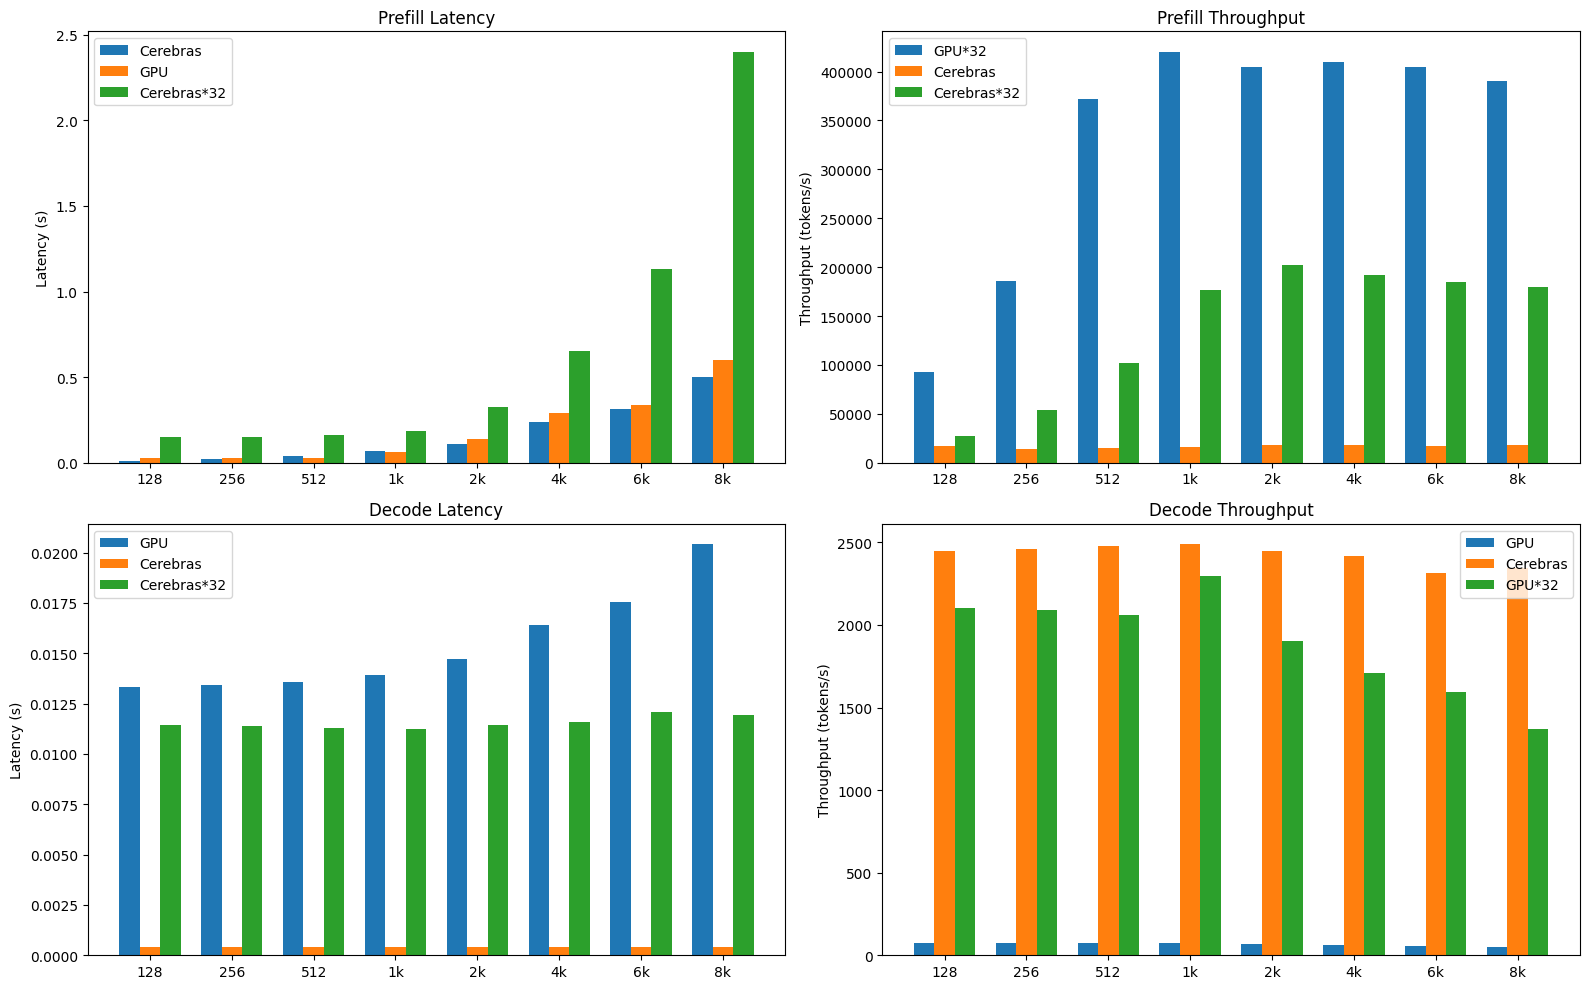

In [151]:
import numpy as np
import matplotlib.pyplot as plt

# x轴
seq = ['128', '256', '512', '1k', '2k', '4k', '6k', '8k']
x = np.arange(len(seq))
width = 0.25

# -----------------------
# Decode Throughput
# -----------------------
gpu_decode = [75, 74.63, 73.6, 71.8, 68, 61, 57, 49]
cer_decode = [2450, 2460, 2480, 2488, 2450, 2415, 2315, 2343]
gpu32_decode = [2100, 2089.64, 2060.8, 2297.6, 1904, 1708, 1596, 1372]

# -----------------------
# Decode Latency
# -----------------------
gpu_lat = [0.0133333333333333, 0.0133994372236366, 0.0135869565217391, 0.0139275766016713,
           0.0147058823529412, 0.0163934426229508, 0.0175438596491228, 0.0204081632653061]

cer_lat = [0.000408163265306122, 0.00040650406504065, 0.000403225806451613, 0.000401929260450161,
           0.000408163265306122, 0.00041407867494824, 0.000431965442764579, 0.000426803243704652]

cer32_lat = [0.0114285714285714, 0.0113821138211382, 0.0112903225806452, 0.0112540192926045,
             0.0114285714285714, 0.0115942028985507, 0.0120950323974082, 0.0119504908237303]

# -----------------------
# Prefill Latency
# -----------------------
cer_prefill_lat = [0.01, 0.02, 0.04, 0.07, 0.11, 0.24, 0.315, 0.5]
gpu_prefill_lat = [0.03, 0.03, 0.03, 0.065, 0.14, 0.29, 0.34, 0.6]
cer_bs32_lat = [0.147874306839187, 0.151658767772512, 0.16, 0.184971098265896,
                0.32520325203252, 0.65040650406504, 1.13, 2.4]

# -----------------------
# Prefill Throughput
# -----------------------
gpu32_prefill = [93090, 186181, 372363, 420102, 404543, 410000, 405000, 390000]
cer_prefill = [17312, 14414, 14937, 16426, 18466, 17994, 17500, 17800]
cer_bs32_prefill = [27699, 54016, 102400, 177152, 202141, 192321, 185000, 180000]

# =======================
# Plot
# =======================
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# ---- 左上: Prefill Latency ----
ax = axs[0, 0]
ax.bar(x - width, cer_prefill_lat, width, label='Cerebras')
ax.bar(x, gpu_prefill_lat, width, label='GPU')
ax.bar(x + width, cer_bs32_lat, width, label='Cerebras*32')
ax.set_title('Prefill Latency')
ax.set_xticks(x)
ax.set_xticklabels(seq)
ax.set_ylabel('Latency (s)')
ax.legend()

# ---- 右上: Prefill Throughput ----
ax = axs[0, 1]
ax.bar(x - width, gpu32_prefill, width, label='GPU*32')
ax.bar(x, cer_prefill, width, label='Cerebras')
ax.bar(x + width, cer_bs32_prefill, width, label='Cerebras*32')
ax.set_title('Prefill Throughput')
ax.set_xticks(x)
ax.set_xticklabels(seq)
ax.set_ylabel('Throughput (tokens/s)')
ax.legend()

# ---- 左下: Decode Latency ----
ax = axs[1, 0]
ax.bar(x - width, gpu_lat, width, label='GPU')
ax.bar(x, cer_lat, width, label='Cerebras')
ax.bar(x + width, cer32_lat, width, label='Cerebras*32')
ax.set_title('Decode Latency')
ax.set_xticks(x)
ax.set_xticklabels(seq)
ax.set_ylabel('Latency (s)')
ax.legend()

# ---- 右下: Decode Throughput ----
ax = axs[1, 1]
ax.bar(x - width, gpu_decode, width, label='GPU')
ax.bar(x, cer_decode, width, label='Cerebras')
ax.bar(x + width, gpu32_decode, width, label='GPU*32')
ax.set_title('Decode Throughput')
ax.set_xticks(x)
ax.set_xticklabels(seq)
ax.set_ylabel('Throughput (tokens/s)')
ax.legend()

plt.tight_layout()
plt.savefig("/Users/huziyu/Downloads/inference.pdf", bbox_inches="tight")
plt.show()

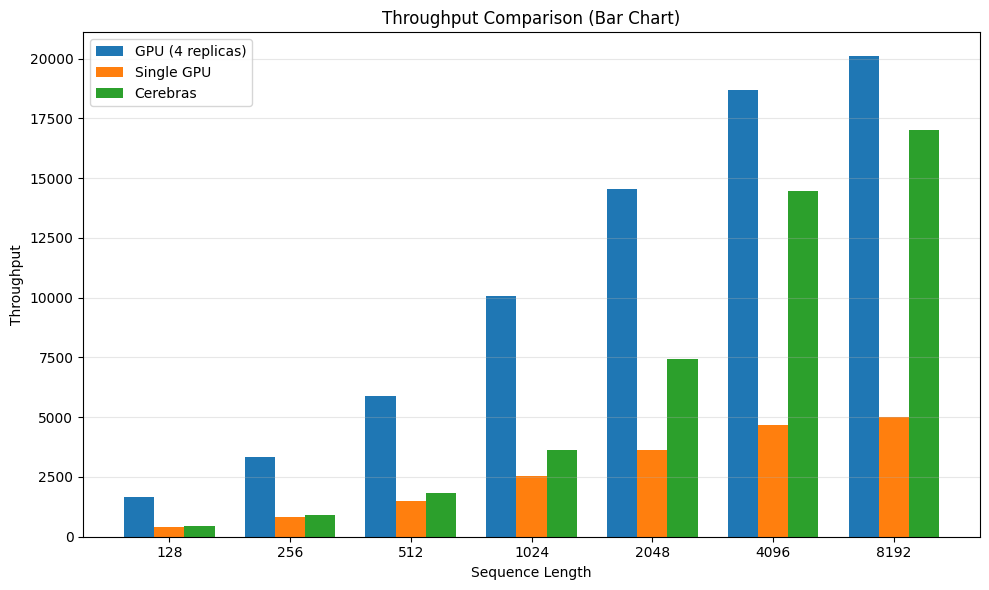

In [152]:
import matplotlib.pyplot as plt
import numpy as np

# x-axis
x_labels = [128, 256, 512, 1024, 2048, 4096, 8192]

# data
gpu = [1678.68852459016, 3324.67532467532, 5902.01729106628,
       10088.6699507389, 14550, 18700, 20100]

single_gpu = [x / 4 for x in gpu]

cerebras = [465.92, 926.72, 1848.32, 3635.2, 7450, 14448, 17000]

# bar positions
x = np.arange(len(x_labels))
width = 0.25

# plot
plt.figure(figsize=(10, 6))
plt.bar(x - width, gpu, width, label='GPU (4 replicas)')
plt.bar(x, single_gpu, width, label='Single GPU')
plt.bar(x + width, cerebras, width, label='Cerebras')

# labels and style
plt.xlabel('Sequence Length')
plt.ylabel('Throughput')
plt.title('Throughput Comparison (Bar Chart)')
plt.xticks(x, x_labels)
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

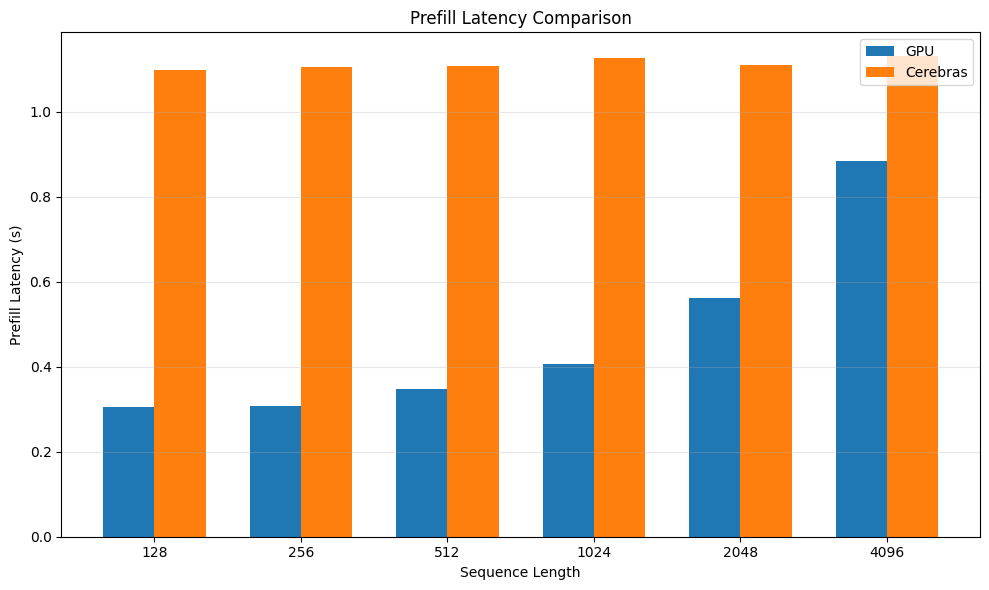

In [153]:
import matplotlib.pyplot as plt
import numpy as np

# x-axis
x_labels = [128, 256, 512, 1024, 2048, 4096]

# data
gpu = [0.305, 0.308, 0.347, 0.406, 0.562, 0.884]
cerebras4 = [1.0989010989011, 1.10497237569061, 1.10803324099723,
             1.12676056338028, 1.11, 1.13]

# bar positions
x = np.arange(len(x_labels))
width = 0.35

# plot
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, gpu, width, label='GPU')
plt.bar(x + width/2, cerebras4, width, label='Cerebras')

# labels and style
plt.xlabel('Sequence Length')
plt.ylabel('Prefill Latency (s)')
plt.title('Prefill Latency Comparison')
plt.xticks(x, x_labels)
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

plt.show()